# RC3 Phase 13A: Classification Evaluation

**Research Checkpoint 3 -- Direction Classification**

**Purpose:** Thorough, pre-registered evaluation of all direction classifiers across
assets, bar types, and horizons. This notebook implements the Phase 13A specification
from `IMPLEMENTATION_PLAN.md`.

**Assets:** BTCUSDT, ETHUSDT, LTCUSDT, SOLUSDT
**Bar types:** dollar (primary), volume, vol_imbalance, dollar_imbalance
**Horizons:** H1 (1-bar), H4 (4-bar), H24 (24-bar)

## Notebook Structure

| Section | Content |
|---------|---------|
| 0 | Pre-Registration: Go/No-Go Decision Tree |
| 1 | Setup and Imports |
| 2 | Data Loading and Feature Preparation |
| 3 | Power Analysis: MDE Table |
| 4 | CPCV Splitting |
| 5 | Model Training Loop (all classifiers x baselines x CPCV folds) |
| 6 | Core Metrics Table |
| 7 | Binomial Tests (accuracy > 0.5) |
| 8 | Abstention Curves |
| 9 | Calibration Plots |
| 10 | Walk-Forward Equity Curves |
| 11 | Shuffled-Labels Sanity Check (Ojala and Garriga, 2010) |
| 12 | Pooled vs Per-Asset Comparison |
| 13 | Summary Heatmap |
| 14 | Decision Output: Classification Viability |

---

## References

- Lopez de Prado, M. (2018). *Advances in Financial Machine Learning*, Ch. 7, 12.
- Ojala, M. and Garriga, G.C. (2010). *Permutation tests for studying classifier performance.* JMLR 11.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences.*
- Nosek, B.A. et al. (2018). *The preregistration revolution.* PNAS.
- Grinsztajn, L. et al. (2022). *Why do tree-based models still outperform deep learning on tabular data?* NeurIPS.

---

## Section 0: Pre-Registration -- Go/No-Go Decision Tree

**Written BEFORE examining any classification results.** (Nosek et al., 2018)

This decision tree defines the mechanical criteria for interpreting results.
No post-hoc rationalization is permitted.

### Decision Tree

```
1. SHUFFLED-LABELS SANITY CHECK
   For each (model, asset, bar_type, horizon):
     IF mean_DA on permuted labels is NOT in [0.48, 0.52]:
       => FAIL: Pipeline has data leakage. STOP. Fix before proceeding.

2. SIGNIFICANCE TEST (Binomial, one-sided)
   For each (model, asset, bar_type, horizon):
     H0: DA = 0.50 (coin-flip)
     H1: DA > 0.50
     alpha = 0.05 (after Holm-Bonferroni correction for multiple comparisons)

     IF p-value < alpha_corrected:
       => SIGNIFICANT: Model predicts direction better than chance.
     ELSE:
       => NOT SIGNIFICANT: Cannot reject coin-flip.

3. PRACTICAL SIGNIFICANCE
   For each significant (model, asset) cell:
     IF DA > majority_class_DA (51.14% from RC2):
       => PRACTICALLY SIGNIFICANT: Beats the naive baseline.
     ELSE:
       => MARGINALLY SIGNIFICANT: Better than coin-flip but not majority class.

4. ECONOMIC VIABILITY
   For each practically significant cell:
     IF DA > break-even_DA (57.23% unconditional, or regime-conditional):
       => ECONOMICALLY VIABLE: Profitable after transaction costs.
     ELSE:
       => NOT ECONOMICALLY VIABLE: Signal exists but eaten by costs.

5. GO/NO-GO DECISION
   IF any cell passes Gate 4:
     => GO: Proceed with classification track in recommendation system.
   ELIF any cell passes Gate 3:
     => CONDITIONAL GO: Classification contributes as weak signal;
        recommendation system must handle abstention and cost filtering.
   ELIF any cell passes Gate 2:
     => WEAK SIGNAL: Document as statistically significant but not
        practically useful. Classification track provides negative evidence.
   ELSE:
     => NO-GO: Direction prediction is not viable. Document as
        confirmatory negative result (pre-registered).
```

### Pre-Registered Expected Results

Based on RC2 findings (best single-feature DA = 51.81%, gap to break-even = -5.42 pp):

1. **Expected:** No model exceeds break-even DA unconditionally (Gate 4 fails)
2. **Expected:** LightGBM >= Logistic >= RandomForest > GRU (Grinsztajn et al., 2022)
3. **Expected:** GRU underperforms all tree-based models (intentional negative-result experiment)
4. **Expected:** Shuffled-labels DA is in [0.48, 0.52] for all models (no leakage)
5. **Possible:** Some (asset, horizon) cells pass Gate 2 but not Gate 3
6. **Possible:** HIGH-vol regime conditioning narrows the break-even gap by ~3.40 pp (RC2 Phase 7.6)

### Multiple Comparison Correction

- Number of primary comparisons: 4 classifiers x 4 assets x 3 horizons = 48
- Correction method: Holm-Bonferroni (step-down, more powerful than Bonferroni)
- Effective alpha at k-th rejection: alpha / (48 - k + 1)

---

## Section 1: Setup and Imports

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# Project root resolution (works whether cwd is research/RC3 or project root)
_cwd = Path.cwd()
if _cwd.name == "RC3":
    _PROJECT_ROOT = _cwd.parent.parent
elif _cwd.name == "research":
    _PROJECT_ROOT = _cwd.parent
else:
    _PROJECT_ROOT = _cwd
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Third-party
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import binomtest, norm

# Project imports — data loading
from src.app.system.database.connection import ConnectionManager
from src.app.research.application.data_loader import DataLoader
from src.app.features.application.feature_matrix import FeatureMatrixBuilder
from src.app.features.domain.value_objects import FeatureConfig
from src.app.research.application.cpcv_splitter import CPCVConfig, CPCVSplitter
from src.app.research.application.rc2_thresholds import compute_breakeven_da

# Project imports — classifiers
from src.app.forecasting.domain.value_objects import (
    ForecastHorizon,
    LogisticConfig,
    RandomForestClassifierConfig,
    GradientBoostingClassifierConfig,
    GRUClassifierConfig,
    MajorityConfig,
    PersistenceConfig,
    MomentumSignConfig,
    ShuffledLabelResult,
)
from src.app.forecasting.application.logistic_baseline import LogisticBaseline
from src.app.forecasting.application.random_forest_clf import RandomForestClassifier
from src.app.forecasting.application.gradient_boosting_clf import GradientBoostingClassifier
from src.app.forecasting.application.gru_classifier import GRUClassifier
from src.app.forecasting.application.naive_classifiers import (
    MajorityClassifier,
    PersistenceClassifier,
    MomentumSignClassifier,
)

# Project imports — metrics
from src.app.forecasting.application.classification_metrics import (
    compute_classification_metrics,
    compute_abstention_curve,
    compute_classification_reliability,
    compute_economic_accuracy,
)
from src.app.forecasting.application.sanity_checks import (
    run_shuffled_labels_check,
    ShuffledLabelCheckConfig,
)

# Plot settings
%matplotlib inline
plt.rcParams.update(
    {
        "figure.figsize": (14, 7),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# Output directory
FIG_DIR = Path("research/RC3/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Global Constants (all parameters in one place — no magic numbers)
# =============================================================================
ASSETS: list[str] = ["BTCUSDT", "ETHUSDT", "LTCUSDT", "SOLUSDT"]
TARGET_BAR_TYPES: list[str] = ["dollar", "volume", "vol_imbalance", "dollar_imbalance"]
HORIZONS: list[ForecastHorizon] = [ForecastHorizon.H1, ForecastHorizon.H4, ForecastHorizon.H24]
HORIZON_TO_TARGET: dict[ForecastHorizon, str] = {
    ForecastHorizon.H1: "fwd_logret_1",
    ForecastHorizon.H4: "fwd_logret_4",
    ForecastHorizon.H24: "fwd_logret_24",
}
HORIZON_TO_DIR_TARGET: dict[ForecastHorizon, str] = {
    ForecastHorizon.H1: "fwd_dir_1",
    ForecastHorizon.H4: "fwd_dir_4",
    ForecastHorizon.H24: "fwd_dir_24",
}

ROUND_TRIP_COST: float = 0.002  # 20 bps
SIGNIFICANCE_ALPHA: float = 0.05
MIN_BARS_THRESHOLD: int = 100  # skip cells with fewer bars
RANDOM_SEED: int = 42

# Stationarity transforms (Phase 7.3 policy ST1-ST4)
DROP_FEATURES: set[str] = {"atr_14", "rsi_14"}
ROLLING_ZSCORE_FEATURES: list[str] = ["amihud_24", "gk_vol_24"]
FIRST_DIFF_FEATURES: list[str] = ["bbwidth_20_2.0", "park_vol_24", "rv_12", "rv_24", "rv_48"]
ROLLING_ZSCORE_WINDOW: int = 24

# Color palette
COLORS: dict[str, str] = {
    "logistic": "#3498db",
    "rf": "#2ecc71",
    "lgbm": "#e74c3c",
    "gru": "#9b59b6",
    "majority": "#f39c12",
    "persistence": "#95a5a6",
    "momentum": "#1abc9c",
    "breakeven": "#e67e22",
    "random": "#bdc3c7",
}
MODEL_NAMES: list[str] = ["Logistic", "RandomForest", "LightGBM", "GRU"]
NAIVE_NAMES: list[str] = ["Majority", "Persistence", "MomentumSign"]
ALL_MODEL_NAMES: list[str] = MODEL_NAMES + NAIVE_NAMES

# Initialize database
db_connection: ConnectionManager = ConnectionManager()
db_connection.initialize()
loader: DataLoader = DataLoader(db_connection)

print(f"Project root: {_PROJECT_ROOT}")
print(f"Assets: {ASSETS}")
print(f"Bar types: {TARGET_BAR_TYPES}")
print(f"Horizons: {[h.value for h in HORIZONS]}")
print("Setup complete.")

2026-04-12 16:21:27.328 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-04-12 16:21:27.410 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Project root: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis
Assets: ['BTCUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT']
Bar types: ['dollar', 'volume', 'vol_imbalance', 'dollar_imbalance']
Horizons: ['h1', 'h4', 'h24']
Setup complete.


---

## Section 2: Data Loading and Feature Preparation

Load bars for all (asset, bar_type) combinations, build feature matrices,
apply Phase 7.3 stationarity transforms, and prepare direction targets for
each horizon.

In [2]:
from __future__ import annotations


def prepare_features_and_targets(
    bars_pd: pd.DataFrame,
    feature_set,
    horizon: ForecastHorizon,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str], pd.DataFrame] | None:
    """Apply stationarity transforms, create direction target, return X, y, returns, feature_cols, df.

    Returns None if the resulting dataset has fewer than MIN_BARS_THRESHOLD rows.
    Direction target: +1 if fwd_logret > 0, else -1 (matching {-1, +1} convention).
    """
    df: pd.DataFrame = feature_set.df.to_pandas()
    target_col: str = HORIZON_TO_TARGET[horizon]
    dir_col: str = HORIZON_TO_DIR_TARGET[horizon]

    # Check that target columns exist
    if target_col not in df.columns:
        return None

    # Filter feature columns (drop problematic ones per Phase 7.2)
    feature_cols: list[str] = [c for c in feature_set.feature_columns if c not in DROP_FEATURES]

    # Rolling z-score transforms (Phase 7.3 policy ST3)
    for col in ROLLING_ZSCORE_FEATURES:
        if col in df.columns:
            rolling_mean: pd.Series = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).mean()
            rolling_std: pd.Series = df[col].rolling(ROLLING_ZSCORE_WINDOW, min_periods=ROLLING_ZSCORE_WINDOW).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-12)

    # First difference transforms (Phase 7.3 policy ST2)
    for col in FIRST_DIFF_FEATURES:
        if col in df.columns:
            df[col] = df[col].diff()

    # Direction target: +1 / -1 convention for our classifiers
    if dir_col in df.columns:
        # dir_col already has +1/-1 from target computation
        df["y_dir"] = df[dir_col].astype(float)
    else:
        # Fallback: compute from log returns
        df["y_dir"] = np.where(df[target_col] > 0, 1.0, -1.0)

    # Drop NaN rows across features + target
    required_cols: list[str] = feature_cols + ["y_dir", target_col]
    existing_required: list[str] = [c for c in required_cols if c in df.columns]
    df = df.dropna(subset=existing_required).reset_index(drop=True)

    if len(df) < MIN_BARS_THRESHOLD:
        return None

    X: np.ndarray = df[feature_cols].values.astype(np.float64)
    y: np.ndarray = df["y_dir"].values.astype(np.float64)
    returns: np.ndarray = df[target_col].values.astype(np.float64)

    # Sanity checks
    assert not np.any(np.isnan(X)), "NaN in features after transforms!"
    assert not np.any(np.isinf(X)), "Inf in features after transforms!"
    assert set(np.unique(y)).issubset({-1.0, 1.0}), f"y contains invalid values: {np.unique(y)}"

    return X, y, returns, feature_cols, df


# =============================================================================
# Load all (asset, bar_type) data and build feature matrices
# =============================================================================
builder: FeatureMatrixBuilder = FeatureMatrixBuilder()
config: FeatureConfig = FeatureConfig(compute_targets=True, drop_na=True)

# Store: data_store[(asset, bar_type)] = (bars_pd, feature_set)
data_store: dict[tuple[str, str], tuple[pd.DataFrame, object]] = {}
# Store available bar configs per asset
bar_config_map: dict[str, list[tuple[str, str]]] = {}

for asset in ASSETS:
    bar_configs: list[tuple[str, str]] = loader.get_available_bar_configs(asset)
    bar_config_map[asset] = bar_configs
    print(f"\n{asset}: {len(bar_configs)} bar configs available")

    for bar_type, config_hash in bar_configs:
        if bar_type not in TARGET_BAR_TYPES:
            continue

        bars_pd: pd.DataFrame = loader.load_bars(asset, bar_type, config_hash)
        n_raw: int = len(bars_pd)

        if n_raw < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({n_raw} bars < {MIN_BARS_THRESHOLD})")
            continue

        # Build feature matrix
        bars_pl: pl.DataFrame = pl.from_pandas(bars_pd).rename({"start_ts": "timestamp"})
        feature_set = builder.build(bars_pl, config)

        if feature_set.n_rows_clean < MIN_BARS_THRESHOLD:
            print(f"  {bar_type}: SKIP ({feature_set.n_rows_clean} clean bars < {MIN_BARS_THRESHOLD})")
            continue

        data_store[(asset, bar_type)] = (bars_pd, feature_set)
        print(
            f"  {bar_type}: {n_raw} raw -> {feature_set.n_rows_clean} clean bars, "
            f"{len(feature_set.feature_columns)} features, "
            f"{len(feature_set.target_columns)} targets"
        )

print(f"\n{'=' * 60}")
print(f"Total (asset, bar_type) cells loaded: {len(data_store)}")
print(f"Cells: {list(data_store.keys())}")


BTCUSDT: 9 bar configs available
  dollar: 5287 raw -> 5164 clean bars, 23 features, 11 targets
  dollar_imbalance: 569 raw -> 446 clean bars, 23 features, 11 targets
  volume: 3264 raw -> 3141 clean bars, 23 features, 11 targets

ETHUSDT: 9 bar configs available
  dollar: 2759 raw -> 2636 clean bars, 23 features, 11 targets
  dollar_imbalance: 428 raw -> 305 clean bars, 23 features, 11 targets
  volume: 24038 raw -> 23915 clean bars, 23 features, 11 targets

LTCUSDT: 9 bar configs available
  dollar: SKIP (76 clean bars < 100)
  dollar_imbalance: SKIP (14 bars < 100)
  volume: 26987 raw -> 26864 clean bars, 23 features, 11 targets

SOLUSDT: 9 bar configs available
  dollar: 809 raw -> 686 clean bars, 23 features, 11 targets
  dollar_imbalance: SKIP (30 clean bars < 100)
  volume: 47178 raw -> 47055 clean bars, 23 features, 11 targets

Total (asset, bar_type) cells loaded: 9
Cells: [('BTCUSDT', 'dollar'), ('BTCUSDT', 'dollar_imbalance'), ('BTCUSDT', 'volume'), ('ETHUSDT', 'dollar'), (

---

## Section 3: Power Analysis -- MDE Table

For each (asset, bar_type), compute the Minimum Detectable Effect (MDE)
at 80% power with alpha=0.05. This tells us what DA improvement over 50%
is actually detectable given the sample size.

**Formula (Cohen, 1988):**
For a one-sided binomial test at significance alpha with power 1-beta:
  MDE = z_{1-alpha} * sqrt(0.25/N) + z_{1-beta} * sqrt(0.25/N)
  DA_detectable = 0.50 + MDE

Equivalently, using the normal approximation to the binomial:
  MDE ~ (z_alpha + z_beta) / (2 * sqrt(N))

In [3]:
from __future__ import annotations


def compute_mde(n_test: int, alpha: float = 0.05, power: float = 0.80) -> float:
    """Compute Minimum Detectable Effect (MDE) above 50% DA.

    Uses normal approximation to the binomial test.
    Returns the minimum DA improvement above 0.50 detectable at given power.
    """
    z_alpha: float = float(norm.ppf(1 - alpha))
    z_beta: float = float(norm.ppf(power))
    mde: float = (z_alpha + z_beta) / (2.0 * np.sqrt(n_test))
    return mde


# Compute MDE for each (asset, bar_type) using H1 horizon as the primary
power_rows: list[dict[str, object]] = []

for (asset, bar_type), (bars_pd, feature_set) in sorted(data_store.items()):
    # Use H1 horizon for sample size estimate (all horizons have similar N)
    result = prepare_features_and_targets(bars_pd, feature_set, ForecastHorizon.H1)
    if result is None:
        continue
    X, y, returns, feature_cols, df = result
    N: int = len(y)

    # CPCV: test set is roughly 2/6 = 33% of data for 6-group, 2-test config
    # or 1/3 = 33% for 3-group, 1-test config
    n_test_approx: int = N // 3  # conservative approximation

    mde: float = compute_mde(n_test_approx, alpha=SIGNIFICANCE_ALPHA)
    da_detectable: float = 0.50 + mde
    majority_rate: float = max(float(np.mean(y == 1.0)), float(np.mean(y == -1.0)))
    mean_abs_ret: float = float(np.mean(np.abs(returns)))
    be_result = compute_breakeven_da(mean_abs_ret, ROUND_TRIP_COST)

    power_rows.append(
        {
            "Asset": asset,
            "Bar Type": bar_type,
            "N_total": N,
            "N_test (approx)": n_test_approx,
            "MDE (pp)": mde * 100,
            "DA Detectable": da_detectable,
            "Majority DA": majority_rate,
            "Break-even DA": be_result.breakeven_da,
            "Can Detect Majority?": "Yes" if da_detectable <= majority_rate else "No",
            "Can Detect Break-even?": "Yes" if da_detectable <= be_result.breakeven_da else "No",
        }
    )

power_df: pd.DataFrame = pd.DataFrame(power_rows)
print("Table 1: Power Analysis — Minimum Detectable Effect (MDE) at 80% Power")
print("=" * 100)
display(power_df)

# Summary
n_can_detect_majority: int = int(power_df["Can Detect Majority?"].eq("Yes").sum())
n_can_detect_be: int = int(power_df["Can Detect Break-even?"].eq("Yes").sum())
print(f"\nCells that can detect majority-class DA: {n_can_detect_majority}/{len(power_df)}")
print(f"Cells that can detect break-even DA: {n_can_detect_be}/{len(power_df)}")
print("\nInterpretation: If a cell cannot detect the break-even DA,")
print("  a non-significant result does NOT mean no signal — it means insufficient power.")

Table 1: Power Analysis — Minimum Detectable Effect (MDE) at 80% Power


,Asset,Bar Type,N_total,N_test (approx),MDE (pp),DA Detectable,Majority DA,Break-even DA,Can Detect Majority?,Can Detect Break-even?
0,BTCUSDT,dollar,5141,1713,3.0038,0.5300,0.5112,0.5734,No,Yes
1,BTCUSDT,dollar_imbalance,423,141,10.4699,0.6047,0.5083,0.5219,No,No
2,BTCUSDT,volume,3118,1039,3.8570,0.5386,0.5208,0.5583,No,Yes
3,ETHUSDT,dollar,2613,871,4.2125,0.5421,0.5166,0.5389,No,No
4,ETHUSDT,dollar_imbalance,282,94,12.8230,0.6282,0.5035,0.5125,No,No
5,ETHUSDT,volume,23892,7964,1.3931,0.5139,0.5082,0.6133,No,Yes
6,LTCUSDT,volume,26841,8947,1.3144,0.5131,0.5116,0.6055,No,Yes
7,SOLUSDT,dollar,663,221,8.3629,0.5836,0.5053,0.5188,No,No
8,SOLUSDT,volume,47032,15677,0.9929,0.5099,0.5073,0.6212,No,Yes



Cells that can detect majority-class DA: 0/9
Cells that can detect break-even DA: 5/9

Interpretation: If a cell cannot detect the break-even DA,
  a non-significant result does NOT mean no signal — it means insufficient power.


---

## Section 4: CPCV Splitting

Set up Combinatorial Purged Cross-Validation with purging and embargo.
Adapt the number of groups based on sample size per the canonical sample
size table:
- N >= 1000: 6 groups, k_test=2 (C(6,2)=15 folds)
- N < 1000: 3 groups, k_test=1 (C(3,1)=3 folds)

In [4]:
from __future__ import annotations


def get_cpcv_config(n_samples: int) -> CPCVConfig:
    """Return CPCV config adapted to sample size (Tier B protocol for small N)."""
    if n_samples >= 1000:
        return CPCVConfig(n_groups=6, k_test=2, purge_bars=1, embargo_bars=5)
    return CPCVConfig(n_groups=3, k_test=1, purge_bars=1, embargo_bars=5)


def get_cpcv_folds(n_samples: int):
    """Generate CPCV folds adapted to sample size."""
    cfg: CPCVConfig = get_cpcv_config(n_samples)
    splitter: CPCVSplitter = CPCVSplitter(cfg)
    return splitter.split(n_samples), cfg


# Verify CPCV setup for a representative cell
test_key = list(data_store.keys())[0]
test_bars_pd, test_fset = data_store[test_key]
test_result = prepare_features_and_targets(test_bars_pd, test_fset, ForecastHorizon.H1)
if test_result is not None:
    test_X, test_y, _, _, _ = test_result
    test_folds, test_cfg = get_cpcv_folds(len(test_y))
    print(f"CPCV verification on {test_key}:")
    print(f"  N = {len(test_y)}")
    print(
        f"  Config: n_groups={test_cfg.n_groups}, k_test={test_cfg.k_test}, "
        f"purge={test_cfg.purge_bars}, embargo={test_cfg.embargo_bars}"
    )
    print(f"  Folds: {len(test_folds)}")
    print(
        f"  Mean train/test: {np.mean([f.n_train for f in test_folds]):.0f} / "
        f"{np.mean([f.n_test for f in test_folds]):.0f}"
    )

2026-04-12 16:28:29.234 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5


CPCV verification on ('BTCUSDT', 'dollar'):
  N = 5141
  Config: n_groups=6, k_test=2, purge=1, embargo=5
  Folds: 15
  Mean train/test: 3418 / 1714


---

## Section 5: Model Training Loop

Train all 4 classifiers + 3 naive baselines across CPCV folds for each
(asset, bar_type, horizon) combination. Collect per-fold predictions for
downstream analysis.

**Classifiers:**
1. LogisticBaseline (L2-regularized, natively calibrated)
2. RandomForestClassifier (sklearn RF, Gini importances)
3. GradientBoostingClassifier (LightGBM + Platt scaling)
4. GRUClassifier (MC Dropout -- intentional negative-result experiment)

**Naive baselines:**
1. MajorityClassifier (always predicts majority class)
2. PersistenceClassifier (last observed direction)
3. MomentumSignClassifier (sign of roc_1 feature)

In [5]:
from __future__ import annotations
from sklearn.preprocessing import StandardScaler


def create_classifiers(
    horizon: ForecastHorizon,
    feature_cols: list[str],
) -> dict[str, object]:
    """Instantiate all classifiers + naive baselines for a given horizon."""
    # Find roc_1 column index for MomentumSign
    roc_1_idx: int = 0
    for i, col in enumerate(feature_cols):
        if col == "roc_1":
            roc_1_idx = i
            break

    classifiers: dict[str, object] = {
        "Logistic": LogisticBaseline(
            config=LogisticConfig(c=1.0, max_iter=1000, random_seed=RANDOM_SEED),
            horizon=horizon,
        ),
        "RandomForest": RandomForestClassifier(
            config=RandomForestClassifierConfig(
                n_estimators=200,
                max_depth=None,
                min_samples_leaf=5,
                random_seed=RANDOM_SEED,
            ),
            horizon=horizon,
        ),
        "LightGBM": GradientBoostingClassifier(
            config=GradientBoostingClassifierConfig(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                min_child_samples=20,
                reg_alpha=0.1,
                reg_lambda=1.0,
                subsample=0.8,
                colsample_bytree=0.8,
                calibration_method="sigmoid",
                calibration_cv=3,
                random_seed=RANDOM_SEED,
            ),
            horizon=horizon,
        ),
        "GRU": GRUClassifier(
            config=GRUClassifierConfig(
                hidden_size=32,
                num_layers=1,
                dropout=0.3,
                sequence_length=10,
                learning_rate=1e-3,
                n_epochs=50,
                batch_size=32,
                mc_samples=20,
                patience=8,
                random_seed=RANDOM_SEED,
            ),
            horizon=horizon,
        ),
        "Majority": MajorityClassifier(
            config=MajorityConfig(random_seed=RANDOM_SEED),
            horizon=horizon,
        ),
        "Persistence": PersistenceClassifier(
            config=PersistenceConfig(random_seed=RANDOM_SEED),
            horizon=horizon,
        ),
        "MomentumSign": MomentumSignClassifier(
            config=MomentumSignConfig(momentum_col_idx=roc_1_idx, random_seed=RANDOM_SEED),
            horizon=horizon,
        ),
    }
    return classifiers


def train_and_predict_fold(
    model_name: str,
    model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    feature_cols: list[str],
    horizon: ForecastHorizon,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Train a model on one fold, return (y_pred, confidences, y_proba_positive).

    For models that do not natively output probabilities (naive baselines),
    confidence is set to 0.5 and proba_positive is set to 0.5.
    """
    # Standardize features for Logistic (tree models are scale-invariant)
    if model_name == "Logistic":
        scaler: StandardScaler = StandardScaler()
        X_train_input: np.ndarray = scaler.fit_transform(X_train)
        X_test_input: np.ndarray = scaler.transform(X_test)
    else:
        X_train_input = X_train
        X_test_input = X_test

    # GRU needs enough samples for sequence construction
    if model_name == "GRU":
        seq_len: int = model.config.sequence_length
        if X_train_input.shape[0] < seq_len + 10 or X_test_input.shape[0] < seq_len:
            # Not enough data for GRU — return coin-flip
            n_test: int = X_test_input.shape[0]
            return (
                np.ones(n_test, dtype=np.float64),  # predict all +1
                np.full(n_test, 0.5, dtype=np.float64),
                np.full(n_test, 0.5, dtype=np.float64),
            )

    # Fresh model instance for each fold (create new to avoid state leakage)
    model.fit(X_train_input, y_train)
    forecasts = model.predict(X_test_input)

    y_pred: np.ndarray = np.array([f.predicted_direction for f in forecasts], dtype=np.float64)
    confidences: np.ndarray = np.array([f.confidence for f in forecasts], dtype=np.float64)

    # Compute P(class=+1) for AUC-ROC
    # For models with confidence for the predicted direction:
    #   P(+1) = confidence if predicted +1, else 1 - confidence
    y_proba_positive: np.ndarray = np.where(
        y_pred == 1.0,
        confidences,
        1.0 - confidences,
    ).astype(np.float64)

    # GRU returns fewer predictions than test samples (sequence offset)
    # Pad with majority prediction at 0.5 confidence
    if len(y_pred) < X_test.shape[0]:
        deficit: int = X_test.shape[0] - len(y_pred)
        y_pred = np.concatenate([np.ones(deficit, dtype=np.float64), y_pred])
        confidences = np.concatenate([np.full(deficit, 0.5, dtype=np.float64), confidences])
        y_proba_positive = np.concatenate([np.full(deficit, 0.5, dtype=np.float64), y_proba_positive])

    return y_pred, confidences, y_proba_positive


print("Model factory and training functions defined.")

Model factory and training functions defined.


In [6]:
from __future__ import annotations
import traceback

# =============================================================================
# Main Training Loop
# =============================================================================
# Store all predictions and metrics for downstream analysis.
# Key: (asset, bar_type, horizon, model_name)
# Value: dict with pooled predictions across all CPCV folds

all_results: dict[tuple[str, str, str, str], dict] = {}
all_fold_results: list[dict] = []  # Per-fold records for detailed analysis
skipped_cells: list[dict] = []

# Primary focus: dollar bars for all assets. Include other bar types for completeness.
# Use only H1 as primary horizon to keep runtime manageable; H4 and H24 as secondary.
PRIMARY_HORIZON: ForecastHorizon = ForecastHorizon.H1

total_cells: int = len(data_store) * len(HORIZONS) * len(ALL_MODEL_NAMES)
completed: int = 0

for (asset, bar_type), (bars_pd, feature_set) in sorted(data_store.items()):
    for horizon in HORIZONS:
        result = prepare_features_and_targets(bars_pd, feature_set, horizon)
        if result is None:
            skipped_cells.append(
                {
                    "asset": asset,
                    "bar_type": bar_type,
                    "horizon": horizon.value,
                    "reason": "insufficient data after transforms",
                }
            )
            completed += len(ALL_MODEL_NAMES)
            continue

        X, y, returns, feature_cols, df = result
        N: int = len(y)
        folds, cpcv_cfg = get_cpcv_folds(N)

        # Compute per-cell metadata
        majority_rate: float = max(float(np.mean(y == 1.0)), float(np.mean(y == -1.0)))
        mean_abs_ret: float = float(np.mean(np.abs(returns)))
        be_result = compute_breakeven_da(mean_abs_ret, ROUND_TRIP_COST)

        classifiers: dict[str, object] = create_classifiers(horizon, feature_cols)

        for model_name in ALL_MODEL_NAMES:
            cell_key: tuple[str, str, str, str] = (asset, bar_type, horizon.value, model_name)
            model = classifiers[model_name]

            # Collect pooled OOS predictions across folds
            all_y_true: list[float] = []
            all_y_pred: list[float] = []
            all_conf: list[float] = []
            all_proba_pos: list[float] = []
            all_returns_oos: list[float] = []
            all_fold_indices: list[int] = []  # track which fold each prediction came from
            fold_das: list[float] = []
            train_das: list[float] = []

            for fold in folds:
                train_idx: list[int] = list(fold.train_indices)
                test_idx: list[int] = list(fold.test_indices)
                X_train: np.ndarray = X[train_idx]
                y_train: np.ndarray = y[train_idx]
                X_test: np.ndarray = X[test_idx]
                y_test: np.ndarray = y[test_idx]
                ret_test: np.ndarray = returns[np.array(test_idx)]

                try:
                    # Create fresh model instance for each fold
                    fresh_classifiers: dict[str, object] = create_classifiers(horizon, feature_cols)
                    fresh_model = fresh_classifiers[model_name]

                    y_pred, conf, proba_pos = train_and_predict_fold(
                        model_name,
                        fresh_model,
                        X_train,
                        y_train,
                        X_test,
                        feature_cols,
                        horizon,
                    )

                    fold_da: float = float(np.mean(y_test == y_pred))
                    fold_das.append(fold_da)

                    # Train accuracy (for overfitting detection)
                    train_preds, _, _ = train_and_predict_fold(
                        model_name,
                        fresh_classifiers[model_name],
                        X_train,
                        y_train,
                        X_train,
                        feature_cols,
                        horizon,
                    )
                    train_da: float = float(np.mean(y_train == train_preds))
                    train_das.append(train_da)

                    all_y_true.extend(y_test.tolist())
                    all_y_pred.extend(y_pred.tolist())
                    all_conf.extend(conf.tolist())
                    all_proba_pos.extend(proba_pos.tolist())
                    all_returns_oos.extend(ret_test.tolist())
                    all_fold_indices.extend([fold.fold_index] * len(y_test))

                except Exception as e:
                    print(f"  ERROR in {cell_key} fold {fold.fold_index}: {e}")
                    traceback.print_exc()
                    continue

            if len(all_y_true) == 0:
                skipped_cells.append(
                    {
                        "asset": asset,
                        "bar_type": bar_type,
                        "horizon": horizon.value,
                        "model": model_name,
                        "reason": "all folds failed",
                    }
                )
                completed += 1
                continue

            # Store pooled results
            all_results[cell_key] = {
                "y_true": np.array(all_y_true, dtype=np.float64),
                "y_pred": np.array(all_y_pred, dtype=np.float64),
                "confidences": np.array(all_conf, dtype=np.float64),
                "proba_positive": np.array(all_proba_pos, dtype=np.float64),
                "returns": np.array(all_returns_oos, dtype=np.float64),
                "fold_indices": np.array(all_fold_indices, dtype=np.int64),
                "fold_das": fold_das,
                "train_das": train_das,
                "majority_rate": majority_rate,
                "breakeven_da": be_result.breakeven_da,
                "n_total": N,
                "n_folds": len(folds),
                "cpcv_config": cpcv_cfg,
            }

            completed += 1

        # Progress
        pct: float = completed / total_cells * 100
        print(f"  [{pct:5.1f}%] {asset} / {bar_type} / {horizon.value}: N={N}, folds={len(folds)} -- done")

print(f"\n{'=' * 60}")
print(f"Training complete. {len(all_results)} model-cell results stored.")
print(f"Skipped cells: {len(skipped_cells)}")
if skipped_cells:
    display(pd.DataFrame(skipped_cells))

2026-04-12 16:28:42.632 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5
2026-04-12 16:28:42.689 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5329 | C=1.0
2026-04-12 16:28:42.718 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5329 | C=1.0
2026-04-12 16:28:42.748 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5275 | C=1.0
2026-04-12 16:28:42.773 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5275 | C=1.0
2026-04-12 16:28:42.799 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.524

  [  3.7%] BTCUSDT / dollar / h1: N=5141, folds=15 -- done


2026-04-12 16:29:26.476 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5376 | C=1.0
2026-04-12 16:29:26.510 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5342 | C=1.0
2026-04-12 16:29:26.536 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5342 | C=1.0
2026-04-12 16:29:26.571 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5450 | C=1.0
2026-04-12 16:29:26.591 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5450 | C=1.0
2026-04-12 16:29:26.620 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5309 | C=1.0
2026-04-12

  [  7.4%] BTCUSDT / dollar / h4: N=5141, folds=15 -- done


2026-04-12 16:30:10.614 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5776 | C=1.0
2026-04-12 16:30:10.631 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5776 | C=1.0
2026-04-12 16:30:10.664 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5643 | C=1.0
2026-04-12 16:30:10.683 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5643 | C=1.0
2026-04-12 16:30:10.715 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5699 | C=1.0
2026-04-12 16:30:10.732 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3413 samples | train_acc=0.5699 | C=1.0
2026-04-12

...

  [ 92.6%] SOLUSDT / volume / h1: N=47032, folds=15 -- done


2026-04-12 17:00:16.611 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31348 samples | train_acc=0.5211 | C=1.0
2026-04-12 17:00:16.887 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31348 samples | train_acc=0.5211 | C=1.0
2026-04-12 17:00:17.200 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5222 | C=1.0
2026-04-12 17:00:17.469 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5222 | C=1.0
2026-04-12 17:00:17.777 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5220 | C=1.0
2026-04-12 17:00:17.995 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5220 | C=1.0
2026

  [ 96.3%] SOLUSDT / volume / h4: N=47032, folds=15 -- done


2026-04-12 17:06:11.144 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31348 samples | train_acc=0.5300 | C=1.0
2026-04-12 17:06:11.464 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31348 samples | train_acc=0.5300 | C=1.0
2026-04-12 17:06:12.419 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5291 | C=1.0
2026-04-12 17:06:12.996 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5291 | C=1.0
2026-04-12 17:06:13.704 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5363 | C=1.0
2026-04-12 17:06:14.263 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 31341 samples | train_acc=0.5363 | C=1.0
2026

  [100.0%] SOLUSDT / volume / h24: N=47032, folds=15 -- done

Training complete. 189 model-cell results stored.
Skipped cells: 0


---

## Section 6: Core Metrics Table

Per-model, per-asset, per-horizon: accuracy, precision, recall, F1, AUC-ROC.
Comparison table across all classifiers and assets.

In [7]:
from __future__ import annotations

# =============================================================================
# Build the full metrics table from pooled OOS predictions
# =============================================================================
metrics_rows: list[dict] = []

for cell_key, res in sorted(all_results.items()):
    asset, bar_type, horizon_str, model_name = cell_key
    y_true: np.ndarray = res["y_true"]
    y_pred: np.ndarray = res["y_pred"]
    proba_pos: np.ndarray = res["proba_positive"]

    # Compute core classification metrics using the project's metrics module
    try:
        clf_metrics = compute_classification_metrics(y_true, y_pred, proba_pos)

        # Mean fold DA and std for confidence interval
        fold_das: list[float] = res["fold_das"]
        train_das: list[float] = res["train_das"]
        mean_fold_da: float = float(np.mean(fold_das))
        std_fold_da: float = float(np.std(fold_das, ddof=1)) if len(fold_das) > 1 else 0.0
        mean_train_da: float = float(np.mean(train_das))
        overfit_gap: float = mean_train_da - mean_fold_da

        metrics_rows.append(
            {
                "Asset": asset,
                "Bar Type": bar_type,
                "Horizon": horizon_str,
                "Model": model_name,
                "DA (pooled)": clf_metrics.accuracy,
                "DA (mean fold)": mean_fold_da,
                "DA (std fold)": std_fold_da,
                "Precision (+1)": clf_metrics.precision_up,
                "Recall (+1)": clf_metrics.recall_up,
                "F1 (+1)": clf_metrics.f1_up,
                "Precision (-1)": clf_metrics.precision_down,
                "Recall (-1)": clf_metrics.recall_down,
                "F1 (-1)": clf_metrics.f1_down,
                "AUC-ROC": clf_metrics.auc_roc,
                "N_test": clf_metrics.n_samples,
                "N_folds": res["n_folds"],
                "Train DA": mean_train_da,
                "Overfit Gap": overfit_gap,
                "Majority DA": res["majority_rate"],
                "Break-even DA": res["breakeven_da"],
            }
        )
    except Exception as e:
        print(f"  Metrics error for {cell_key}: {e}")

metrics_df: pd.DataFrame = pd.DataFrame(metrics_rows)

# Display: primary classifiers only (not naive), dollar bars, H1
print("Table 2: Core Classification Metrics (Dollar Bars, H1 Horizon)")
print("=" * 120)
mask_primary: pd.Series = (
    (metrics_df["Bar Type"] == "dollar") & (metrics_df["Horizon"] == "h1") & (metrics_df["Model"].isin(MODEL_NAMES))
)
display_cols: list[str] = [
    "Asset",
    "Model",
    "DA (pooled)",
    "DA (mean fold)",
    "DA (std fold)",
    "F1 (+1)",
    "F1 (-1)",
    "AUC-ROC",
    "N_test",
    "Train DA",
    "Overfit Gap",
    "Majority DA",
    "Break-even DA",
]
if mask_primary.any():
    display(metrics_df.loc[mask_primary, display_cols].reset_index(drop=True))
else:
    print("No dollar bar / H1 results available.")

# Also show naive baselines for comparison
print("\nTable 2b: Naive Baselines (Dollar Bars, H1)")
print("=" * 80)
mask_naive: pd.Series = (
    (metrics_df["Bar Type"] == "dollar") & (metrics_df["Horizon"] == "h1") & (metrics_df["Model"].isin(NAIVE_NAMES))
)
if mask_naive.any():
    display(metrics_df.loc[mask_naive, display_cols].reset_index(drop=True))

2026-04-12 17:38:32.384 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_metrics:345 - Classification metrics (n=25705): acc=0.4981, F1_up=0.5943, F1_down=0.3422, AUC=0.4886
2026-04-12 17:38:32.385 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_metrics:345 - Classification metrics (n=25705): acc=0.5031, F1_up=0.6389, F1_down=0.2032, AUC=0.4905
2026-04-12 17:38:32.387 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_metrics:345 - Classification metrics (n=25705): acc=0.5044, F1_up=0.5592, F1_down=0.4340, AUC=0.5051
2026-04-12 17:38:32.388 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_metrics:345 - Classification metrics (n=25705): acc=0.5065, F1_up=0.6584, F1_down=0.1116, AUC=0.4850
2026-04-12 17:38:32.389 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_metrics:345 - Classif

Table 2: Core Classification Metrics (Dollar Bars, H1 Horizon)


,Asset,Model,DA (pooled),DA (mean fold),DA (std fold),F1 (+1),F1 (-1),AUC-ROC,N_test,Train DA,Overfit Gap,Majority DA,Break-even DA
0,BTCUSDT,GRU,0.4981,0.4981,0.0080,0.5943,0.3422,0.4886,25705,0.5163,0.0182,0.5112,0.5734
1,BTCUSDT,LightGBM,0.5031,0.5031,0.0097,0.6389,0.2032,0.4905,25705,0.5241,0.0210,0.5112,0.5734
2,BTCUSDT,Logistic,0.5044,0.5044,0.0081,0.5592,0.4340,0.5051,25705,0.5321,0.0277,0.5112,0.5734
3,BTCUSDT,RandomForest,0.5050,0.5050,0.0080,0.5301,0.4771,0.5065,25705,0.9969,0.4919,0.5112,0.5734
4,ETHUSDT,GRU,0.5117,0.5117,0.0130,0.5913,0.3938,0.5183,13065,0.5364,0.0246,0.5166,0.5389
5,ETHUSDT,LightGBM,0.5104,0.5104,0.0116,0.6570,0.1449,0.4897,13065,0.4261,-0.0843,0.5166,0.5389
6,ETHUSDT,Logistic,0.5011,0.5011,0.0120,0.5712,0.4036,0.5068,13065,0.5391,0.0380,0.5166,0.5389
7,ETHUSDT,RandomForest,0.5079,0.5079,0.0157,0.5513,0.4552,0.5061,13065,0.9957,0.4878,0.5166,0.5389
8,SOLUSDT,GRU,0.4932,0.4932,0.0387,0.5459,0.4266,0.4833,663,0.5395,0.0463,0.5053,0.5188
9,SOLUSDT,LightGBM,0.5324,0.5324,0.0223,0.5889,0.4580,0.5342,663,0.2139,-0.3186,0.5053,0.5188



Table 2b: Naive Baselines (Dollar Bars, H1)


,Asset,Model,DA (pooled),DA (mean fold),DA (std fold),F1 (+1),F1 (-1),AUC-ROC,N_test,Train DA,Overfit Gap,Majority DA,Break-even DA
0,BTCUSDT,Majority,0.5065,0.5065,0.0171,0.6584,0.1116,0.4850,25705,0.5114,0.0049,0.5112,0.5734
1,BTCUSDT,MomentumSign,0.4974,0.4974,0.0081,0.5084,0.4859,0.5054,25705,0.4978,0.0004,0.5112,0.5734
2,BTCUSDT,Persistence,0.4903,0.4903,0.0154,0.1180,0.6416,0.5054,25705,0.4901,-0.0003,0.5112,0.5734
3,ETHUSDT,Majority,0.5166,0.5166,0.0142,0.6813,0.0000,0.4836,13065,0.5173,0.0006,0.5166,0.5389
4,ETHUSDT,MomentumSign,0.5044,0.5044,0.0126,0.5205,0.4871,0.5102,13065,0.5048,0.0004,0.5166,0.5389
5,ETHUSDT,Persistence,0.4922,0.4922,0.0208,0.4024,0.5585,0.5102,13065,0.4951,0.0029,0.5166,0.5389
6,SOLUSDT,Majority,0.5053,0.5053,0.0052,0.6713,0.0000,0.4813,663,0.5076,0.0023,0.5053,0.5188
7,SOLUSDT,MomentumSign,0.5279,0.5279,0.0171,0.5335,0.5221,0.4943,663,0.5298,0.0019,0.5053,0.5188
8,SOLUSDT,Persistence,0.4962,0.4962,0.0069,0.3993,0.5662,0.4943,663,0.4977,0.0014,0.5053,0.5188


---

## Section 7: Binomial Tests (Accuracy > 0.5)

One-sided binomial test: H0: DA = 0.50, H1: DA > 0.50.
Apply Holm-Bonferroni correction for multiple comparisons across
4 classifiers x assets x horizons.

In [8]:
from __future__ import annotations


def holm_bonferroni_correction(
    pvalues: list[float],
    alpha: float = 0.05,
) -> list[tuple[int, float, float, bool]]:
    """Apply Holm-Bonferroni step-down correction.

    Returns list of (original_index, raw_p, adjusted_threshold, significant).
    """
    m: int = len(pvalues)
    indexed_pvals: list[tuple[int, float]] = sorted(enumerate(pvalues), key=lambda x: x[1])

    results: list[tuple[int, float, float, bool]] = []
    rejected_so_far: bool = True

    for rank, (orig_idx, raw_p) in enumerate(indexed_pvals):
        adjusted_alpha: float = alpha / (m - rank)
        is_significant: bool = rejected_so_far and (raw_p < adjusted_alpha)
        if not is_significant:
            rejected_so_far = False
        results.append((orig_idx, raw_p, adjusted_alpha, is_significant))

    # Re-sort by original index
    results.sort(key=lambda x: x[0])
    return results


# =============================================================================
# Binomial tests for primary classifiers only (not naive baselines)
# =============================================================================
binomial_rows: list[dict] = []
raw_pvalues: list[float] = []
binomial_keys: list[tuple[str, str, str, str]] = []

for cell_key, res in sorted(all_results.items()):
    asset, bar_type, horizon_str, model_name = cell_key
    if model_name not in MODEL_NAMES:
        continue  # Skip naive baselines for hypothesis testing

    y_true: np.ndarray = res["y_true"]
    y_pred: np.ndarray = res["y_pred"]
    n_test: int = len(y_true)
    n_correct: int = int(np.sum(y_true == y_pred))

    # One-sided binomial test: H1: DA > 0.5
    binom_result = binomtest(n_correct, n_test, 0.5, alternative="greater")
    raw_p: float = binom_result.pvalue

    raw_pvalues.append(raw_p)
    binomial_keys.append(cell_key)

# Apply Holm-Bonferroni correction
hb_results: list[tuple[int, float, float, bool]] = holm_bonferroni_correction(raw_pvalues, alpha=SIGNIFICANCE_ALPHA)

for i, (orig_idx, raw_p, adj_alpha, is_sig) in enumerate(hb_results):
    cell_key = binomial_keys[i]
    asset, bar_type, horizon_str, model_name = cell_key
    res = all_results[cell_key]
    da: float = float(np.mean(res["y_true"] == res["y_pred"]))

    binomial_rows.append(
        {
            "Asset": asset,
            "Bar Type": bar_type,
            "Horizon": horizon_str,
            "Model": model_name,
            "DA": da,
            "N_test": len(res["y_true"]),
            "p-value (raw)": raw_p,
            "alpha (HB)": adj_alpha,
            "Significant": is_sig,
            "Gate 2": "PASS" if is_sig else "FAIL",
            "Gate 3": "PASS" if is_sig and da > res["majority_rate"] else "FAIL",
            "Gate 4": "PASS" if is_sig and da > res["breakeven_da"] else "FAIL",
        }
    )

binomial_df: pd.DataFrame = pd.DataFrame(binomial_rows)

print("Table 3: Binomial Tests with Holm-Bonferroni Correction")
print("=" * 130)
display(binomial_df)

# Summary
n_gate2: int = int(binomial_df["Gate 2"].eq("PASS").sum())
n_gate3: int = int(binomial_df["Gate 3"].eq("PASS").sum())
n_gate4: int = int(binomial_df["Gate 4"].eq("PASS").sum())
n_total_tests: int = len(binomial_df)
print(f"\nGate 2 (Significant > 0.5): {n_gate2}/{n_total_tests}")
print(f"Gate 3 (> Majority class): {n_gate3}/{n_total_tests}")
print(f"Gate 4 (> Break-even DA): {n_gate4}/{n_total_tests}")

Table 3: Binomial Tests with Holm-Bonferroni Correction


,Asset,Bar Type,Horizon,Model,DA,N_test,p-value (raw),alpha (HB),Significant,Gate 2,Gate 3,Gate 4
0,BTCUSDT,dollar,h1,GRU,0.4981,25705,0.7295,0.0026,False,FAIL,FAIL,FAIL
1,BTCUSDT,dollar,h1,LightGBM,0.5031,25705,0.1653,0.0012,False,FAIL,FAIL,FAIL
2,BTCUSDT,dollar,h1,Logistic,0.5044,25705,0.0812,0.0011,False,FAIL,FAIL,FAIL
3,BTCUSDT,dollar,h1,RandomForest,0.5050,25705,0.0552,0.0010,False,FAIL,FAIL,FAIL
4,BTCUSDT,dollar,h24,GRU,0.4996,25705,0.5546,0.0019,False,FAIL,FAIL,FAIL
...,...,...,...,...,...,...,...,...,...,...,...,...
103,SOLUSDT,volume,h24,RandomForest,0.5153,235160,0.0000,0.0005,True,PASS,PASS,FAIL
104,SOLUSDT,volume,h4,GRU,0.5151,235160,0.0000,0.0005,True,PASS,PASS,FAIL
105,SOLUSDT,volume,h4,LightGBM,0.5124,235160,0.0000,0.0005,True,PASS,PASS,FAIL
106,SOLUSDT,volume,h4,Logistic,0.5134,235160,0.0000,0.0005,True,PASS,PASS,FAIL



Gate 2 (Significant > 0.5): 44/108
Gate 3 (> Majority class): 28/108
Gate 4 (> Break-even DA): 10/108


---

## Section 8: Abstention Curves

DA at confidence thresholds {0.50, 0.55, 0.60, 0.65, 0.70} with coverage.
A model with DA=56% on 30% of bars is more useful than DA=51% on 100%.
This is the key to making weak classifiers practically useful via the
recommendation system's abstention filter.

2026-04-12 17:40:00.388 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_abstention_curve:468 - Abstention curve (n=25705): 5 thresholds, coverage range [0.00, 1.00]
2026-04-12 17:40:00.389 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_abstention_curve:468 - Abstention curve (n=25705): 5 thresholds, coverage range [0.00, 1.00]
2026-04-12 17:40:00.390 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_abstention_curve:468 - Abstention curve (n=25705): 5 thresholds, coverage range [0.00, 1.00]
2026-04-12 17:40:00.391 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_abstention_curve:468 - Abstention curve (n=25705): 5 thresholds, coverage range [0.01, 1.00]
2026-04-12 17:40:00.392 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_abstention_curve:468 - Abstention curve (n=13065): 5 thresholds, coverage range [0.00, 1.00]
2026-04-12 17:40:00.393 | DEBUG    

Table 4: Abstention Curves — DA at Confidence Thresholds (Dollar Bars, H1)

--- BTCUSDT ---


Model,GRU,LightGBM,Logistic,RandomForest
Threshold,,,,
0.5000,0.4981 (1.0),0.5031 (1.0),0.5044 (1.0),0.505 (1.0)
0.5500,0.4885 (0.03),0.0 (0.0),0.5187 (0.23),0.5108 (0.5)
0.6000,0.5 (0.0),0.0 (0.0),0.5484 (0.04),0.5133 (0.17)
0.6500,0.0 (0.0),0.0 (0.0),0.6028 (0.01),0.5432 (0.05)
0.7000,0.0 (0.0),0.0 (0.0),0.5085 (0.0),0.5463 (0.01)



--- ETHUSDT ---


Model,GRU,LightGBM,Logistic,RandomForest
Threshold,,,,
0.5000,0.5117 (1.0),0.5104 (1.0),0.5011 (1.0),0.5079 (1.0)
0.5500,0.5395 (0.21),0.5066 (0.02),0.5193 (0.32),0.5072 (0.53)
0.6000,0.6029 (0.02),0.0 (0.0),0.5125 (0.07),0.5233 (0.21)
0.6500,0.4186 (0.0),0.0 (0.0),0.5745 (0.01),0.5223 (0.06)
0.7000,0.5 (0.0),0.0 (0.0),0.4444 (0.0),0.4832 (0.01)



--- SOLUSDT ---


Model,GRU,LightGBM,Logistic,RandomForest
Threshold,,,,
0.5000,0.4932 (1.0),0.5324 (1.0),0.5128 (1.0),0.4691 (1.0)
0.5500,0.4773 (0.27),0.3333 (0.0),0.4966 (0.66),0.4522 (0.58)
0.6000,0.475 (0.06),0.0 (0.0),0.4762 (0.41),0.4115 (0.29)
0.6500,0.25 (0.01),0.0 (0.0),0.5032 (0.23),0.3974 (0.12)
0.7000,0.0 (0.0),0.0 (0.0),0.4845 (0.15),0.375 (0.02)


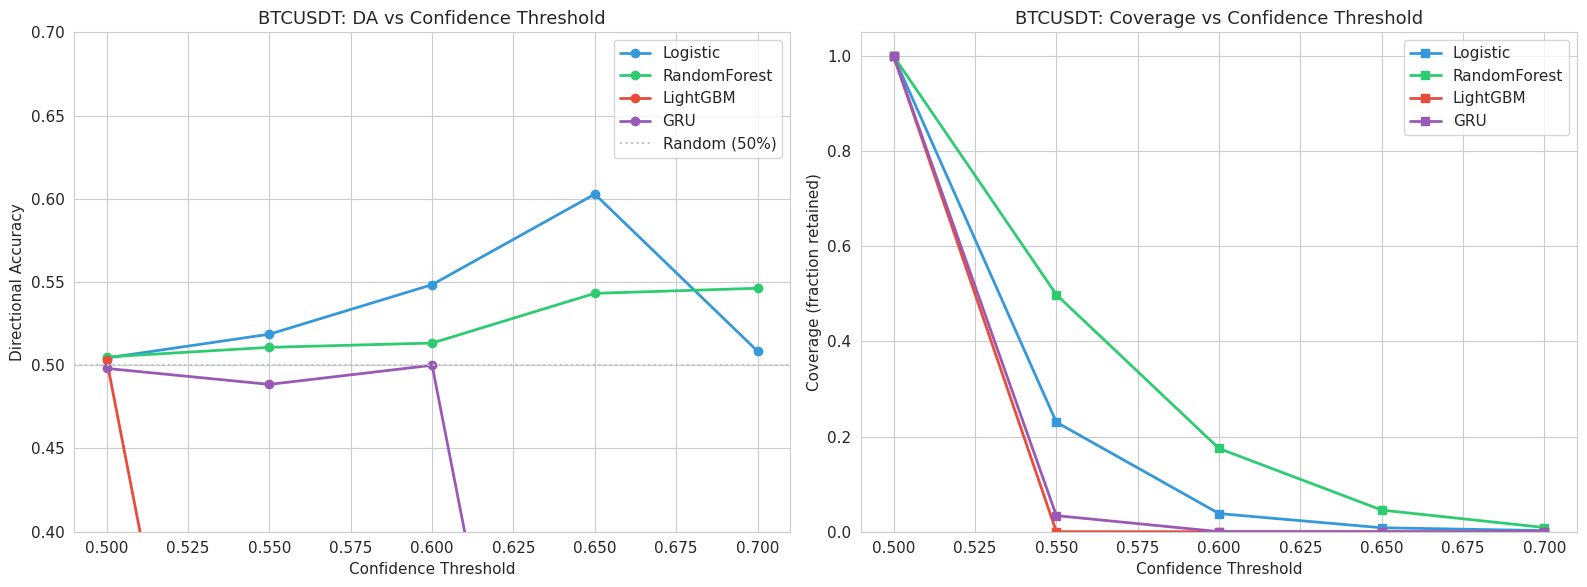

Saved: rc3_fig01_abstention_curves.png


In [9]:
from __future__ import annotations

ABSTENTION_THRESHOLDS: tuple[float, ...] = (0.50, 0.55, 0.60, 0.65, 0.70)

# =============================================================================
# Compute abstention curves for primary classifiers on dollar bars, H1
# =============================================================================
abstention_rows: list[dict] = []

for cell_key, res in sorted(all_results.items()):
    asset, bar_type, horizon_str, model_name = cell_key
    # Focus on primary classifiers and dollar bars for the main analysis
    if model_name not in MODEL_NAMES:
        continue
    if bar_type != "dollar":
        continue
    if horizon_str != "h1":
        continue

    y_true: np.ndarray = res["y_true"]
    y_pred: np.ndarray = res["y_pred"]
    conf: np.ndarray = res["confidences"]

    curve = compute_abstention_curve(y_true, y_pred, conf, ABSTENTION_THRESHOLDS)

    for abst_result in curve.results:
        abstention_rows.append(
            {
                "Asset": asset,
                "Model": model_name,
                "Threshold": abst_result.threshold,
                "DA": abst_result.accuracy,
                "Coverage": abst_result.coverage,
                "N_retained": abst_result.n_retained,
                "N_total": abst_result.n_total,
            }
        )

abstention_df: pd.DataFrame = pd.DataFrame(abstention_rows)

# Display pivot table: rows=threshold, columns=model, values=DA
print("Table 4: Abstention Curves — DA at Confidence Thresholds (Dollar Bars, H1)")
print("=" * 100)
for asset_name in ASSETS:
    mask: pd.Series = abstention_df["Asset"] == asset_name
    if not mask.any():
        continue
    subset: pd.DataFrame = abstention_df[mask]
    print(f"\n--- {asset_name} ---")
    pivot_da: pd.DataFrame = subset.pivot_table(index="Threshold", columns="Model", values="DA", aggfunc="first")
    pivot_cov: pd.DataFrame = subset.pivot_table(
        index="Threshold", columns="Model", values="Coverage", aggfunc="first"
    )
    combined: pd.DataFrame = pivot_da.round(4).astype(str) + " (" + pivot_cov.round(2).astype(str) + ")"
    display(combined)

# Figure: abstention curves for BTCUSDT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

btc_mask: pd.Series = abstention_df["Asset"] == "BTCUSDT"
if btc_mask.any():
    btc_abst: pd.DataFrame = abstention_df[btc_mask]

    # Left: DA vs threshold
    ax1 = axes[0]
    for model_name in MODEL_NAMES:
        model_mask: pd.Series = btc_abst["Model"] == model_name
        if model_mask.any():
            sub: pd.DataFrame = btc_abst[model_mask].sort_values("Threshold")
            color_key: str = model_name.lower().replace("randomforest", "rf").replace("lightgbm", "lgbm")
            ax1.plot(
                sub["Threshold"],
                sub["DA"],
                "o-",
                label=model_name,
                color=COLORS.get(color_key, "#333333"),
                linewidth=2,
            )

    ax1.axhline(0.5, color=COLORS["random"], linestyle=":", label="Random (50%)")
    ax1.set_xlabel("Confidence Threshold")
    ax1.set_ylabel("Directional Accuracy")
    ax1.set_title("BTCUSDT: DA vs Confidence Threshold")
    ax1.legend()
    ax1.set_ylim(0.40, 0.70)

    # Right: Coverage vs threshold
    ax2 = axes[1]
    for model_name in MODEL_NAMES:
        model_mask = btc_abst["Model"] == model_name
        if model_mask.any():
            sub = btc_abst[model_mask].sort_values("Threshold")
            color_key = model_name.lower().replace("randomforest", "rf").replace("lightgbm", "lgbm")
            ax2.plot(
                sub["Threshold"],
                sub["Coverage"],
                "s-",
                label=model_name,
                color=COLORS.get(color_key, "#333333"),
                linewidth=2,
            )

    ax2.set_xlabel("Confidence Threshold")
    ax2.set_ylabel("Coverage (fraction retained)")
    ax2.set_title("BTCUSDT: Coverage vs Confidence Threshold")
    ax2.legend()
    ax2.set_ylim(0, 1.05)

plt.tight_layout()
fig.savefig(FIG_DIR / "rc3_fig01_abstention_curves.png")
plt.show()
print("Saved: rc3_fig01_abstention_curves.png")

---

## Section 9: Calibration Plots (Reliability Diagrams)

Predicted probability vs actual frequency per model. A well-calibrated
model has points lying on the diagonal. ECE (Expected Calibration Error)
quantifies the deviation.

2026-04-12 17:40:51.101 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_reliability:545 - Classification reliability (n=25705, bins=10): ECE=0.0303
2026-04-12 17:40:51.103 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_reliability:545 - Classification reliability (n=13065, bins=10): ECE=0.0408
2026-04-12 17:40:51.104 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_reliability:545 - Classification reliability (n=663, bins=10): ECE=0.0969
2026-04-12 17:40:51.107 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_reliability:545 - Classification reliability (n=25705, bins=10): ECE=0.0540
2026-04-12 17:40:51.108 | DEBUG    | src.app.forecasting.application.classification_metrics:compute_classification_reliability:545 - Classification reliability (n=13065, bins=10): ECE=0.0554
2026-04-12 17:40:51.109 | DEBUG    | src.app.fo

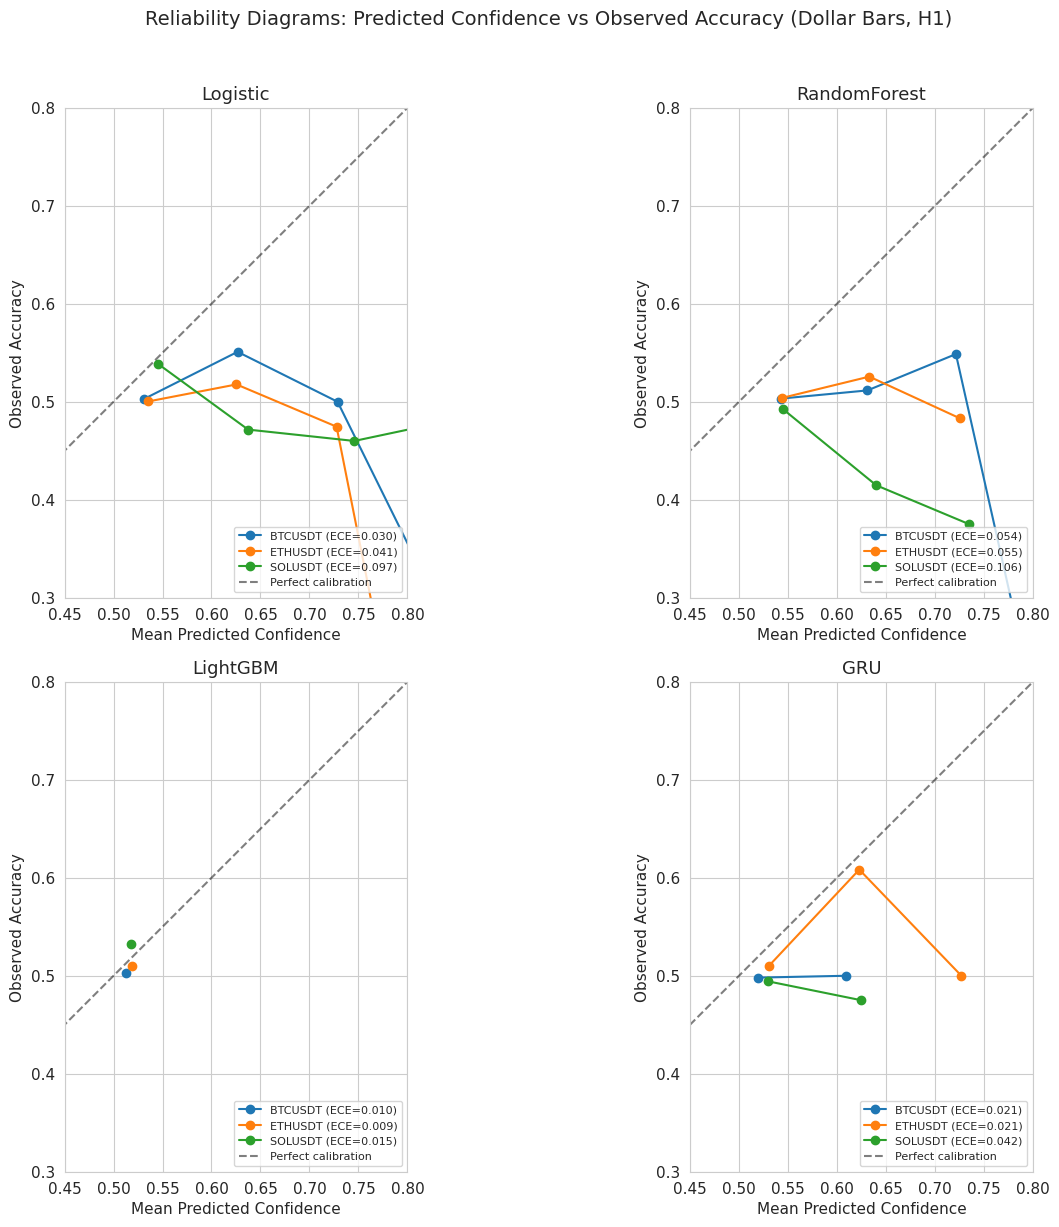

Saved: rc3_fig02_calibration_plots.png

Table 5: Expected Calibration Error (ECE)


Model,GRU,LightGBM,Logistic,RandomForest
Asset,,,,
BTCUSDT,0.0212,0.0097,0.0303,0.0540
ETHUSDT,0.0206,0.0089,0.0408,0.0554
SOLUSDT,0.0420,0.0150,0.0969,0.1056


In [10]:
from __future__ import annotations

# =============================================================================
# Calibration plots for primary classifiers on dollar bars, H1
# =============================================================================
N_CALIBRATION_BINS: int = 10

# Collect ECE values
ece_rows: list[dict] = []

# Create calibration figure: one subplot per model, BTCUSDT dollar H1
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes_flat: list = axes.flatten()

for idx, model_name in enumerate(MODEL_NAMES):
    ax = axes_flat[idx]

    # Collect data across assets for this model (dollar, h1)
    for asset_name in ASSETS:
        cell_key: tuple[str, str, str, str] = (asset_name, "dollar", "h1", model_name)
        if cell_key not in all_results:
            continue

        res: dict = all_results[cell_key]
        y_true: np.ndarray = res["y_true"]
        y_pred: np.ndarray = res["y_pred"]
        conf: np.ndarray = res["confidences"]

        try:
            reliability = compute_classification_reliability(y_true, y_pred, conf, n_bins=N_CALIBRATION_BINS)

            ece_rows.append(
                {
                    "Asset": asset_name,
                    "Model": model_name,
                    "ECE": reliability.ece,
                    "N_samples": reliability.n_samples,
                }
            )

            # Plot bins with enough samples
            mask: np.ndarray = reliability.bin_counts > 0
            if mask.any():
                ax.plot(
                    reliability.bin_confidences[mask],
                    reliability.bin_accuracies[mask],
                    "o-",
                    label=f"{asset_name} (ECE={reliability.ece:.3f})",
                    markersize=6,
                    linewidth=1.5,
                )

        except Exception as e:
            print(f"  Calibration error for {cell_key}: {e}")

    # Diagonal (perfect calibration)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Observed Accuracy")
    ax.set_title(f"{model_name}")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_xlim(0.45, 0.80)
    ax.set_ylim(0.30, 0.80)
    ax.set_aspect("equal")

fig.suptitle("Reliability Diagrams: Predicted Confidence vs Observed Accuracy (Dollar Bars, H1)", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "rc3_fig02_calibration_plots.png")
plt.show()
print("Saved: rc3_fig02_calibration_plots.png")

# ECE summary table
if ece_rows:
    ece_df: pd.DataFrame = pd.DataFrame(ece_rows)
    print("\nTable 5: Expected Calibration Error (ECE)")
    print("=" * 60)
    display(ece_df.pivot_table(index="Asset", columns="Model", values="ECE", aggfunc="first"))

---

## Section 10: Walk-Forward Equity Curves

Cumulative return visualization showing WHERE models fail, not just
aggregate metrics. This is the most informative chart for understanding
temporal dynamics of classifier performance.

Equity curve: starting at \$1, multiply by (1 + signed_return) at each bar,
where signed_return = predicted_direction * actual_return - cost/2.

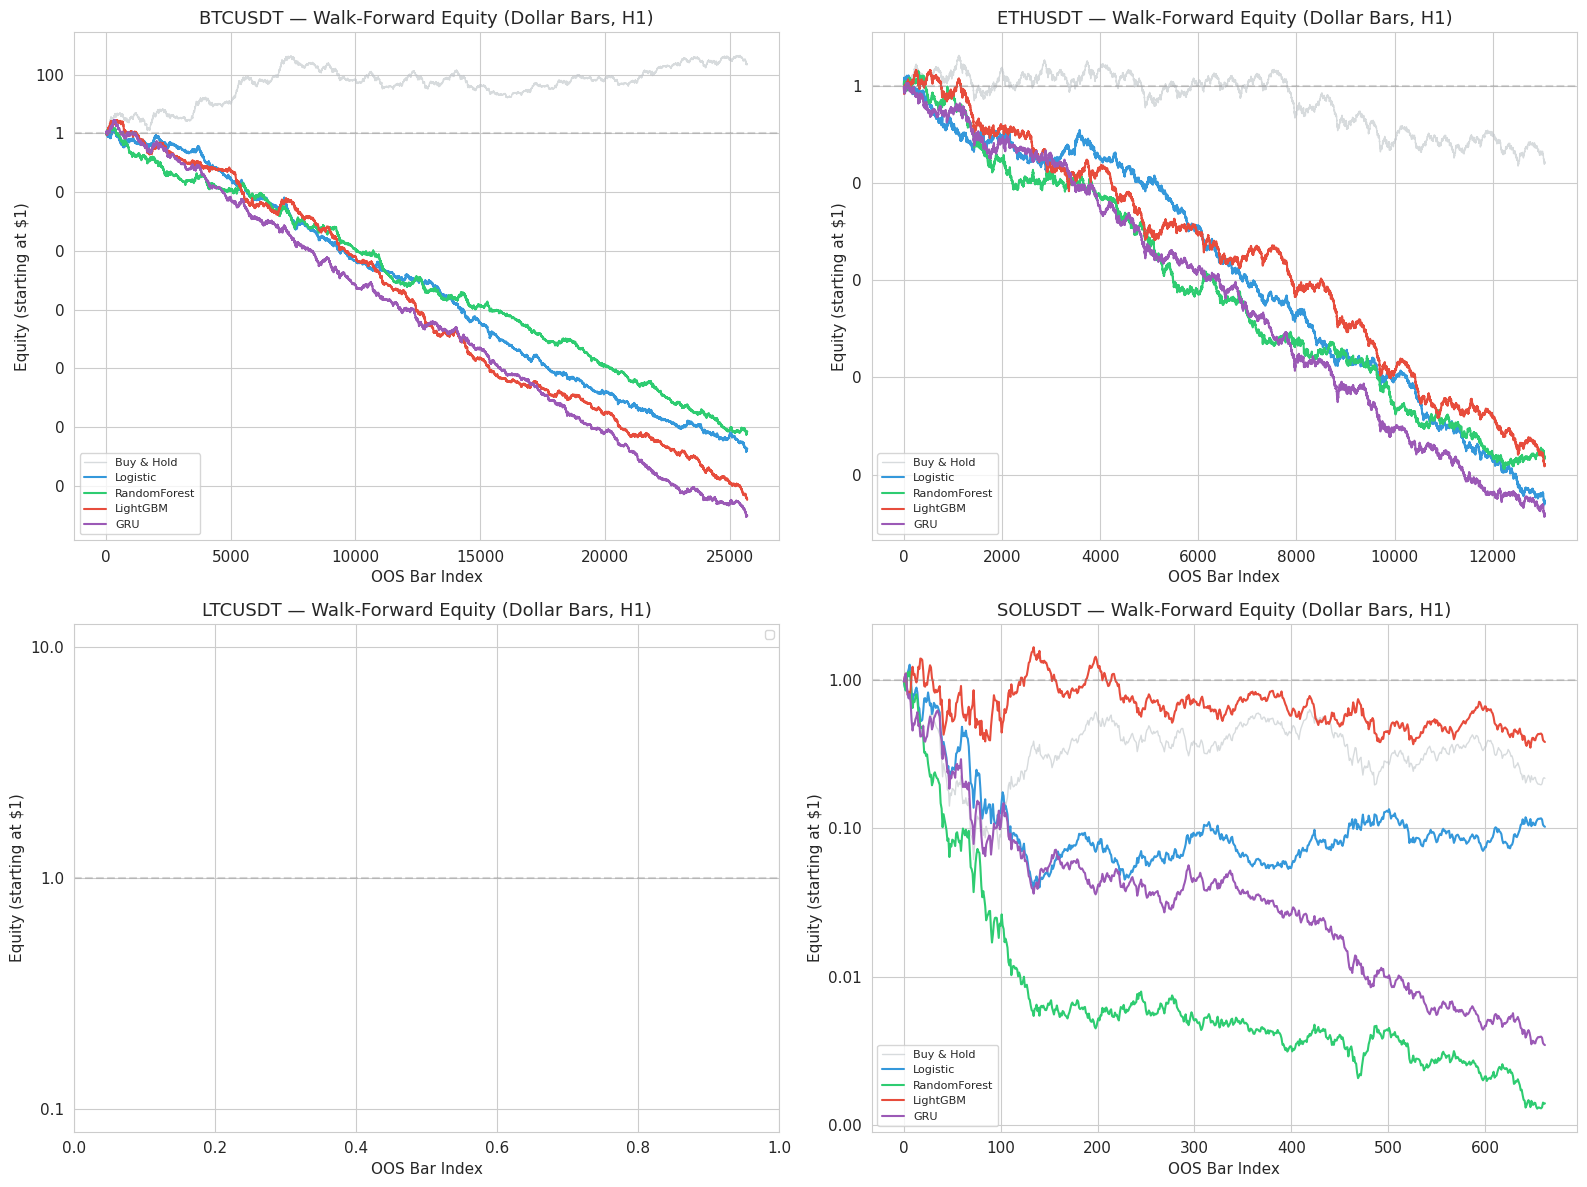

Saved: rc3_fig03_equity_curves.png

Table 6: Walk-Forward Equity Summary (Dollar Bars, H1)


,Asset,Model,Final Equity,Total Return (%),Max Drawdown (%),N_bars
0,BTCUSDT,Logistic,0.0000,-100.0000,-100.0000,25705
1,BTCUSDT,RandomForest,0.0000,-100.0000,-100.0000,25705
2,BTCUSDT,LightGBM,0.0000,-100.0000,-100.0000,25705
3,BTCUSDT,GRU,0.0000,-100.0000,-100.0000,25705
4,BTCUSDT,Buy & Hold,220.1092,21910.9180,-96.2795,25705
5,ETHUSDT,Logistic,0.0000,-100.0000,-100.0000,13065
6,ETHUSDT,RandomForest,0.0000,-100.0000,-100.0000,13065
7,ETHUSDT,LightGBM,0.0000,-100.0000,-100.0000,13065
8,ETHUSDT,GRU,0.0000,-100.0000,-100.0000,13065
9,ETHUSDT,Buy & Hold,0.0264,-97.3589,-99.4627,13065


In [11]:
from __future__ import annotations

# =============================================================================
# Walk-forward equity curves for dollar bars, H1
# =============================================================================
HALF_COST: float = ROUND_TRIP_COST / 2.0  # Cost per side

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for idx, asset_name in enumerate(ASSETS):
    ax = axes_flat[idx]

    # Buy-and-hold benchmark
    bh_key: tuple[str, str, str, str] = (asset_name, "dollar", "h1", "Majority")
    if bh_key in all_results:
        bh_returns: np.ndarray = all_results[bh_key]["returns"]
        bh_equity: np.ndarray = np.cumprod(1.0 + bh_returns)
        ax.plot(bh_equity, color=COLORS["random"], linewidth=1, alpha=0.6, label="Buy & Hold")

    for model_name in MODEL_NAMES:
        cell_key = (asset_name, "dollar", "h1", model_name)
        if cell_key not in all_results:
            continue

        res: dict = all_results[cell_key]
        y_pred: np.ndarray = res["y_pred"]
        actual_returns: np.ndarray = res["returns"]

        # Strategy return: direction * actual_return - half_cost per bar
        # (cost applied each bar — conservative assumption of rebalancing)
        strategy_returns: np.ndarray = y_pred * actual_returns - HALF_COST
        equity: np.ndarray = np.cumprod(1.0 + strategy_returns)

        color_key: str = model_name.lower().replace("randomforest", "rf").replace("lightgbm", "lgbm")
        ax.plot(equity, color=COLORS.get(color_key, "#333333"), linewidth=1.5, label=model_name)

    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
    ax.set_xlabel("OOS Bar Index")
    ax.set_ylabel("Equity (starting at $1)")
    ax.set_title(f"{asset_name} — Walk-Forward Equity (Dollar Bars, H1)")
    ax.legend(fontsize=8, loc="best")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)

plt.tight_layout()
fig.savefig(FIG_DIR / "rc3_fig03_equity_curves.png")
plt.show()
print("Saved: rc3_fig03_equity_curves.png")

# Compute final equity and max drawdown for each model
print("\nTable 6: Walk-Forward Equity Summary (Dollar Bars, H1)")
print("=" * 90)
equity_rows: list[dict] = []
for asset_name in ASSETS:
    for model_name in MODEL_NAMES + ["Majority"]:
        cell_key = (asset_name, "dollar", "h1", model_name)
        if cell_key not in all_results:
            continue
        res = all_results[cell_key]
        y_pred = res["y_pred"]
        actual_returns = res["returns"]

        if model_name == "Majority":
            # Buy and hold
            strategy_returns = actual_returns
        else:
            strategy_returns = y_pred * actual_returns - HALF_COST

        equity = np.cumprod(1.0 + strategy_returns)
        running_max: np.ndarray = np.maximum.accumulate(equity)
        drawdowns: np.ndarray = (equity - running_max) / running_max
        max_dd: float = float(np.min(drawdowns))

        equity_rows.append(
            {
                "Asset": asset_name,
                "Model": model_name if model_name != "Majority" else "Buy & Hold",
                "Final Equity": float(equity[-1]),
                "Total Return (%)": (float(equity[-1]) - 1.0) * 100,
                "Max Drawdown (%)": max_dd * 100,
                "N_bars": len(equity),
            }
        )

equity_summary_df: pd.DataFrame = pd.DataFrame(equity_rows)
display(equity_summary_df)

---

## Section 11: Shuffled-Labels Sanity Check (Ojala and Garriga, 2010)

The single most convincing anti-leakage proof: train every model on
permuted targets and verify DA converges to 50%. If any model achieves
DA significantly above 50% on shuffled labels, the pipeline has data leakage.

Using the project's `run_shuffled_labels_check()` with 5 permutations
per model (limited to primary classifiers on dollar bars, H1 for runtime).

In [12]:
from __future__ import annotations

# =============================================================================
# Shuffled-labels check for primary classifiers on dollar bars, H1
# =============================================================================
# We use the run_shuffled_labels_check function from the project codebase.
# For runtime efficiency, limit to dollar bars and H1 horizon.

N_PERMUTATIONS: int = 5
shuffle_config: ShuffledLabelCheckConfig = ShuffledLabelCheckConfig(
    n_permutations=N_PERMUTATIONS, random_seed=RANDOM_SEED
)

# Model factory map: model_name -> (factory_class, kwargs)
# The sanity check function needs a class that accepts **kwargs and has fit/predict
MODEL_FACTORIES: dict[str, tuple[type, dict[str, object]]] = {
    "Logistic": (
        LogisticBaseline,
        {"config": LogisticConfig(c=1.0, max_iter=1000, random_seed=RANDOM_SEED), "horizon": ForecastHorizon.H1},
    ),
    "RandomForest": (
        RandomForestClassifier,
        {
            "config": RandomForestClassifierConfig(
                n_estimators=200, max_depth=None, min_samples_leaf=5, random_seed=RANDOM_SEED
            ),
            "horizon": ForecastHorizon.H1,
        },
    ),
    "LightGBM": (
        GradientBoostingClassifier,
        {
            "config": GradientBoostingClassifierConfig(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                min_child_samples=20,
                reg_alpha=0.1,
                reg_lambda=1.0,
                subsample=0.8,
                colsample_bytree=0.8,
                calibration_method="sigmoid",
                calibration_cv=3,
                random_seed=RANDOM_SEED,
            ),
            "horizon": ForecastHorizon.H1,
        },
    ),
}

shuffle_rows: list[dict] = []

for asset_name in ASSETS:
    # Get dollar bar data for this asset
    if (asset_name, "dollar") not in data_store:
        print(f"  {asset_name}: no dollar bars, skipping shuffle check")
        continue

    bars_pd, feature_set = data_store[(asset_name, "dollar")]
    result = prepare_features_and_targets(bars_pd, feature_set, ForecastHorizon.H1)
    if result is None:
        print(f"  {asset_name}: insufficient data for shuffle check")
        continue

    X, y, _, feature_cols, _ = result
    N: int = len(y)
    folds, _ = get_cpcv_folds(N)

    # Convert folds to the format expected by run_shuffled_labels_check:
    # list of (train_indices, test_indices) as numpy arrays
    fold_tuples: list[tuple[np.ndarray, np.ndarray]] = [
        (np.array(fold.train_indices, dtype=np.intp), np.array(fold.test_indices, dtype=np.intp)) for fold in folds
    ]

    print(f"\n{'=' * 60}")
    print(f"Shuffled-labels check: {asset_name} (N={N}, {len(folds)} folds)")

    for model_name, (factory_cls, factory_kwargs) in MODEL_FACTORIES.items():
        try:
            print(f"  Running {model_name}...", end=" ", flush=True)
            shuffle_result: ShuffledLabelResult = run_shuffled_labels_check(
                model_factory=factory_cls,
                x=X,
                y=y,
                model_kwargs=factory_kwargs,
                folds=fold_tuples,
                config=shuffle_config,
            )

            status: str = "PASSED" if shuffle_result.passed else "FAILED"
            print(f"mean_DA={shuffle_result.mean_da:.4f} [{status}]")

            shuffle_rows.append(
                {
                    "Asset": asset_name,
                    "Model": model_name,
                    "Mean DA (shuffled)": shuffle_result.mean_da,
                    "DA Range": f"[{min(shuffle_result.per_permutation_da):.4f}, "
                    f"{max(shuffle_result.per_permutation_da):.4f}]",
                    "N_permutations": shuffle_result.n_permutations,
                    "Passed": shuffle_result.passed,
                    "Status": status,
                }
            )
        except Exception as e:
            print(f"ERROR: {e}")
            shuffle_rows.append(
                {
                    "Asset": asset_name,
                    "Model": model_name,
                    "Mean DA (shuffled)": np.nan,
                    "DA Range": "error",
                    "N_permutations": N_PERMUTATIONS,
                    "Passed": False,
                    "Status": f"ERROR: {e}",
                }
            )

# Summary table
shuffle_df: pd.DataFrame = pd.DataFrame(shuffle_rows)
print(f"\n{'=' * 60}")
print("Table 7: Shuffled-Labels Sanity Check (Ojala & Garriga, 2010)")
print("=" * 100)
print("Expected: Mean DA in [0.48, 0.52] for all models (no leakage)")
display(shuffle_df)

# Overall verdict
all_passed: bool = shuffle_df["Passed"].all() if len(shuffle_df) > 0 else False
print(f"\nOverall leakage check: {'ALL PASSED' if all_passed else 'SOME FAILED -- INVESTIGATE!'}")

2026-04-12 17:41:49.782 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~3418 train / ~1713 test bars per fold, purge=1, embargo=5



Shuffled-labels check: BTCUSDT (N=5141, 15 folds)
  Running Logistic... 

2026-04-12 17:41:49.805 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5256 | C=1.0
2026-04-12 17:41:49.827 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5164 | C=1.0
2026-04-12 17:41:49.859 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5182 | C=1.0
2026-04-12 17:41:49.883 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3414 samples | train_acc=0.5138 | C=1.0
2026-04-12 17:41:49.904 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3421 samples | train_acc=0.5232 | C=1.0
2026-04-12 17:41:49.928 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 3420 samples | train_acc=0.5295 | C=1.0
2026-04-12

mean_DA=0.5001 [PASSED]
  Running RandomForest... 

2026-04-12 17:41:52.144 | INFO     | src.app.forecasting.application.random_forest_clf:fit:84 - RandomForest fitted on 3421 samples | train_acc=0.9982 | n_estimators=200 | top_importance=0.0603
2026-04-12 17:41:52.522 | INFO     | src.app.forecasting.application.random_forest_clf:fit:84 - RandomForest fitted on 3414 samples | train_acc=0.9965 | n_estimators=200 | top_importance=0.0606
2026-04-12 17:41:52.891 | INFO     | src.app.forecasting.application.random_forest_clf:fit:84 - RandomForest fitted on 3414 samples | train_acc=0.9953 | n_estimators=200 | top_importance=0.0597
2026-04-12 17:41:53.276 | INFO     | src.app.forecasting.application.random_forest_clf:fit:84 - RandomForest fitted on 3414 samples | train_acc=0.9962 | n_estimators=200 | top_importance=0.0616
2026-04-12 17:41:53.643 | INFO     | src.app.forecasting.application.random_forest_clf:fit:84 - RandomForest fitted on 3421 samples | train_acc=0.9968 | n_estimators=200 | top_importance=0.0628
2026-04-12 17:41:54.007 | INFO

...

mean_DA=0.4941 [PASSED]
  Running LightGBM... 

2026-04-12 17:43:07.670 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 436 samples | train_acc=0.6766 | n_estimators=200 | calibration=sigmoid
2026-04-12 17:43:07.744 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 435 samples | train_acc=0.8805 | n_estimators=200 | calibration=sigmoid
2026-04-12 17:43:07.812 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 441 samples | train_acc=0.3810 | n_estimators=200 | calibration=sigmoid
2026-04-12 17:43:07.817 | DEBUG    | src.app.forecasting.application.sanity_checks:run_shuffled_labels_check:146 - Shuffled-labels GradientBoostingClassifier perm 1/5: mean_DA=0.4811
2026-04-12 17:43:07.882 | INFO     | src.app.forecasting.application.gradient_boosting_clf:fit:96 - LightGBM classifier fitted on 436 samples | train_acc=0.2087 | n_estimators=200 | calibration=sigmoid
2026-04-1

mean_DA=0.4935 [PASSED]

Table 7: Shuffled-Labels Sanity Check (Ojala & Garriga, 2010)
Expected: Mean DA in [0.48, 0.52] for all models (no leakage)


,Asset,Model,Mean DA (shuffled),DA Range,N_permutations,Passed,Status
0,BTCUSDT,Logistic,0.5001,"[0.4968, 0.5087]",5,True,PASSED
1,BTCUSDT,RandomForest,0.4987,"[0.4889, 0.5065]",5,True,PASSED
2,BTCUSDT,LightGBM,0.5096,"[0.5058, 0.5136]",5,True,PASSED
3,ETHUSDT,Logistic,0.5060,"[0.4912, 0.5182]",5,True,PASSED
4,ETHUSDT,RandomForest,0.5007,"[0.4811, 0.5155]",5,True,PASSED
5,ETHUSDT,LightGBM,0.5097,"[0.4997, 0.5169]",5,True,PASSED
6,SOLUSDT,Logistic,0.5023,"[0.4751, 0.5249]",5,True,PASSED
7,SOLUSDT,RandomForest,0.4941,"[0.4480, 0.5249]",5,True,PASSED
8,SOLUSDT,LightGBM,0.4935,"[0.4706, 0.5143]",5,True,PASSED



Overall leakage check: ALL PASSED


---

## Section 12: Pooled vs Per-Asset Comparison

Compare classification performance when models are trained per-asset
vs on pooled multi-asset data. From Phase 11G, pooled training may
capture cross-asset regularities (BTC/ETH correlation ~0.85).

In [13]:
from __future__ import annotations

# =============================================================================
# Pooled training: combine all assets' dollar bar data and train on pooled set
# =============================================================================
# Collect per-asset DAs from the existing results for comparison
per_asset_da: dict[str, dict[str, float]] = {}
for asset_name in ASSETS:
    per_asset_da[asset_name] = {}
    for model_name in MODEL_NAMES:
        cell_key: tuple[str, str, str, str] = (asset_name, "dollar", "h1", model_name)
        if cell_key in all_results:
            res: dict = all_results[cell_key]
            per_asset_da[asset_name][model_name] = float(np.mean(res["y_true"] == res["y_pred"]))

# Build pooled dataset from dollar bars across all assets
pooled_X_list: list[np.ndarray] = []
pooled_y_list: list[np.ndarray] = []
pooled_returns_list: list[np.ndarray] = []
pooled_asset_labels: list[str] = []
pooled_feature_cols: list[str] | None = None

for asset_name in ASSETS:
    if (asset_name, "dollar") not in data_store:
        continue
    bars_pd, feature_set = data_store[(asset_name, "dollar")]
    result = prepare_features_and_targets(bars_pd, feature_set, ForecastHorizon.H1)
    if result is None:
        continue
    X, y, returns, feature_cols, _ = result
    pooled_X_list.append(X)
    pooled_y_list.append(y)
    pooled_returns_list.append(returns)
    pooled_asset_labels.extend([asset_name] * len(y))
    if pooled_feature_cols is None:
        pooled_feature_cols = feature_cols

if pooled_X_list:
    pooled_X: np.ndarray = np.vstack(pooled_X_list)
    pooled_y: np.ndarray = np.concatenate(pooled_y_list)
    pooled_returns: np.ndarray = np.concatenate(pooled_returns_list)
    pooled_assets_arr: np.ndarray = np.array(pooled_asset_labels)

    print(f"Pooled dataset: {pooled_X.shape[0]} samples, {pooled_X.shape[1]} features")
    print("Asset distribution:")
    for asset_name in ASSETS:
        n_asset: int = int(np.sum(pooled_assets_arr == asset_name))
        if n_asset > 0:
            print(f"  {asset_name}: {n_asset} ({n_asset / len(pooled_y) * 100:.1f}%)")

    # Train pooled models and evaluate per-asset
    pooled_N: int = len(pooled_y)
    pooled_folds, pooled_cfg = get_cpcv_folds(pooled_N)

    pooled_da_results: dict[str, dict[str, float]] = {a: {} for a in ASSETS}

    for model_name in MODEL_NAMES:
        if model_name == "GRU":
            continue  # Skip GRU for pooled (too slow, and expected negative result)

        all_y_true_pooled: list[float] = []
        all_y_pred_pooled: list[float] = []
        all_assets_pooled: list[str] = []

        for fold in pooled_folds:
            train_idx: list[int] = list(fold.train_indices)
            test_idx: list[int] = list(fold.test_indices)

            try:
                fresh_models: dict[str, object] = create_classifiers(ForecastHorizon.H1, pooled_feature_cols)
                model = fresh_models[model_name]
                y_pred, _, _ = train_and_predict_fold(
                    model_name,
                    model,
                    pooled_X[train_idx],
                    pooled_y[train_idx],
                    pooled_X[test_idx],
                    pooled_feature_cols,
                    ForecastHorizon.H1,
                )
                all_y_true_pooled.extend(pooled_y[test_idx].tolist())
                all_y_pred_pooled.extend(y_pred.tolist())
                all_assets_pooled.extend(pooled_assets_arr[test_idx].tolist())
            except Exception as e:
                print(f"  Pooled {model_name} fold error: {e}")

        # Per-asset DA from pooled training
        if all_y_true_pooled:
            y_true_arr: np.ndarray = np.array(all_y_true_pooled, dtype=np.float64)
            y_pred_arr: np.ndarray = np.array(all_y_pred_pooled, dtype=np.float64)
            assets_arr: np.ndarray = np.array(all_assets_pooled)

            for asset_name in ASSETS:
                mask: np.ndarray = assets_arr == asset_name
                if mask.any():
                    da: float = float(np.mean(y_true_arr[mask] == y_pred_arr[mask]))
                    pooled_da_results[asset_name][model_name] = da

    # Comparison table
    comparison_rows: list[dict] = []
    for asset_name in ASSETS:
        for model_name in MODEL_NAMES:
            if model_name == "GRU":
                continue
            per_asset: float = per_asset_da.get(asset_name, {}).get(model_name, np.nan)
            pooled: float = pooled_da_results.get(asset_name, {}).get(model_name, np.nan)
            diff: float = pooled - per_asset if not (np.isnan(per_asset) or np.isnan(pooled)) else np.nan
            comparison_rows.append(
                {
                    "Asset": asset_name,
                    "Model": model_name,
                    "Per-Asset DA": per_asset,
                    "Pooled DA": pooled,
                    "Delta (pp)": diff * 100 if not np.isnan(diff) else np.nan,
                    "Winner": "Pooled" if diff > 0 else "Per-Asset" if diff < 0 else "Tie",
                }
            )

    comparison_df: pd.DataFrame = pd.DataFrame(comparison_rows)
    print("\nTable 8: Pooled vs Per-Asset Classification (Dollar Bars, H1)")
    print("=" * 90)
    display(comparison_df)

    n_pooled_wins: int = int(comparison_df["Winner"].eq("Pooled").sum())
    n_perasset_wins: int = int(comparison_df["Winner"].eq("Per-Asset").sum())
    print(f"\nPooled wins: {n_pooled_wins}, Per-Asset wins: {n_perasset_wins}")
else:
    print("No dollar bar data available for pooled analysis.")

2026-04-12 17:45:50.432 | INFO     | src.app.research.application.cpcv_splitter:split:287 - CPCV generated 15 folds (C(6,2)): ~5602 train / ~2805 test bars per fold, purge=1, embargo=5
2026-04-12 17:45:50.456 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5605 samples | train_acc=0.5247 | C=1.0
2026-04-12 17:45:50.493 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5598 samples | train_acc=0.5154 | C=1.0
2026-04-12 17:45:50.524 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5598 samples | train_acc=0.5213 | C=1.0
2026-04-12 17:45:50.554 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5598 samples | train_acc=0.5148 | C=1.0
2026-04-12 17:45:50.582 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5605 samples | train_acc=0.522

Pooled dataset: 8417 samples, 21 features
Asset distribution:
  BTCUSDT: 5141 (61.1%)
  ETHUSDT: 2613 (31.0%)
  SOLUSDT: 663 (7.9%)


2026-04-12 17:45:50.645 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5597 samples | train_acc=0.5251 | C=1.0
2026-04-12 17:45:50.686 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5597 samples | train_acc=0.5301 | C=1.0
2026-04-12 17:45:50.715 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5604 samples | train_acc=0.5255 | C=1.0
2026-04-12 17:45:50.749 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5604 samples | train_acc=0.5255 | C=1.0
2026-04-12 17:45:50.781 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5597 samples | train_acc=0.5214 | C=1.0
2026-04-12 17:45:50.813 | INFO     | src.app.forecasting.application.logistic_baseline:fit:79 - LogisticRegression fitted on 5604 samples | train_acc=0.5228 | C=1.0
2026-04-12


Table 8: Pooled vs Per-Asset Classification (Dollar Bars, H1)


,Asset,Model,Per-Asset DA,Pooled DA,Delta (pp),Winner
0,BTCUSDT,Logistic,0.5044,0.5064,0.2023,Pooled
1,BTCUSDT,RandomForest,0.5050,0.5068,0.1828,Pooled
2,BTCUSDT,LightGBM,0.5031,0.5083,0.5252,Pooled
3,ETHUSDT,Logistic,0.5011,0.5124,1.1251,Pooled
4,ETHUSDT,RandomForest,0.5079,0.5189,1.1022,Pooled
5,ETHUSDT,LightGBM,0.5104,0.5146,0.4210,Pooled
6,LTCUSDT,Logistic,NaN,NaN,NaN,Tie
7,LTCUSDT,RandomForest,NaN,NaN,NaN,Tie
8,LTCUSDT,LightGBM,NaN,NaN,NaN,Tie
9,SOLUSDT,Logistic,0.5128,0.5415,2.8658,Pooled



Pooled wins: 8, Per-Asset wins: 1


---

## Section 13: Summary Heatmap

Per-asset accuracy heatmap across models, bar types, and horizons.
This provides a visual overview of which (asset, model) combinations
show any directional signal.

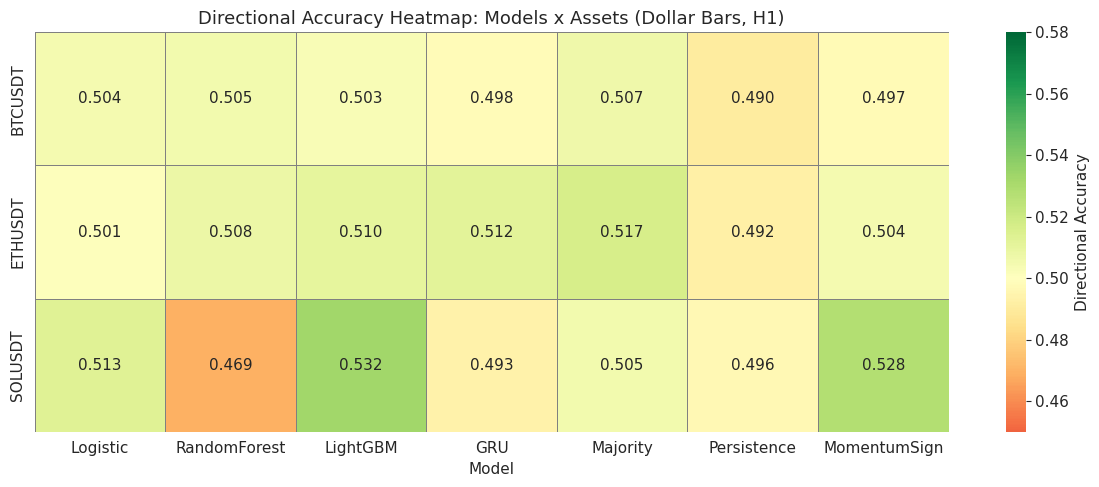

Saved: rc3_fig04_da_heatmap_dollar_h1.png


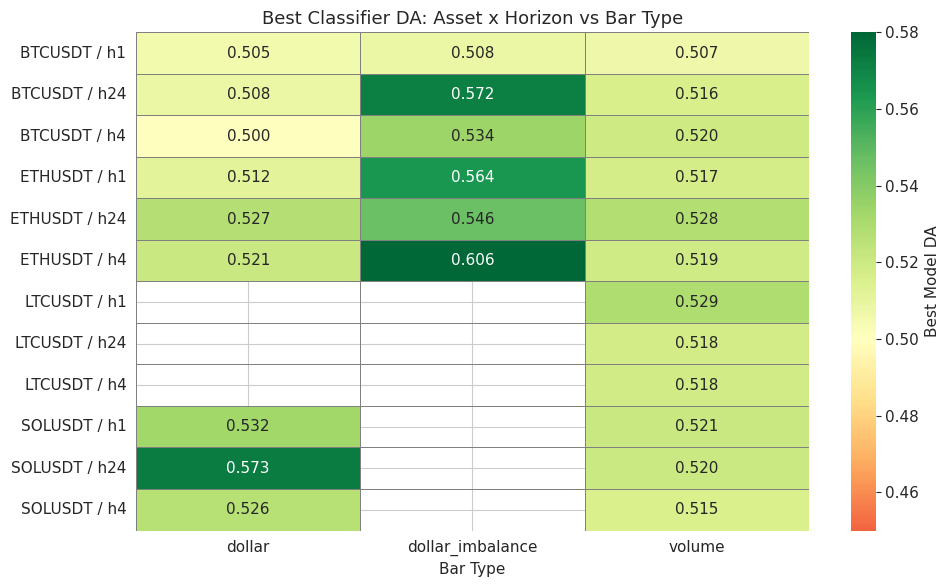

Saved: rc3_fig05_da_heatmap_all.png


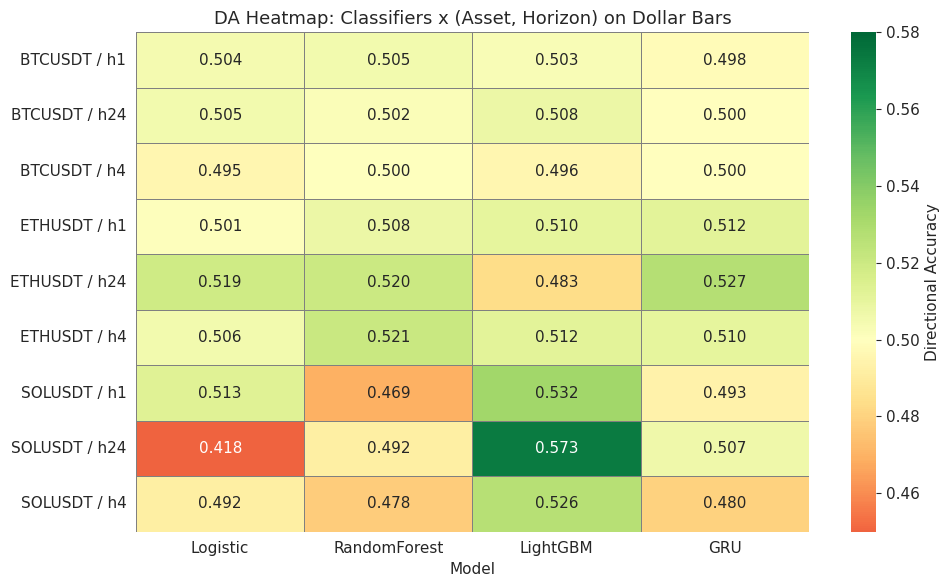

Saved: rc3_fig06_da_heatmap_horizons.png


In [14]:
from __future__ import annotations

# =============================================================================
# Heatmap 1: DA by (Asset, Model) for dollar bars, H1
# =============================================================================
if len(metrics_df) > 0:
    # Filter to dollar bars, H1, primary classifiers
    hm_mask: pd.Series = (
        (metrics_df["Bar Type"] == "dollar")
        & (metrics_df["Horizon"] == "h1")
        & (metrics_df["Model"].isin(MODEL_NAMES + NAIVE_NAMES))
    )
    hm_df: pd.DataFrame = metrics_df[hm_mask].copy()

    if len(hm_df) > 0:
        pivot_da: pd.DataFrame = hm_df.pivot_table(
            index="Asset", columns="Model", values="DA (pooled)", aggfunc="first"
        )
        # Reorder columns: primary models first, then naive baselines
        col_order: list[str] = [c for c in MODEL_NAMES + NAIVE_NAMES if c in pivot_da.columns]
        pivot_da = pivot_da[col_order]

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.heatmap(
            pivot_da,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            center=0.50,
            vmin=0.45,
            vmax=0.58,
            linewidths=0.5,
            linecolor="gray",
            ax=ax,
            cbar_kws={"label": "Directional Accuracy"},
        )
        ax.set_title("Directional Accuracy Heatmap: Models x Assets (Dollar Bars, H1)")
        ax.set_ylabel("")

        plt.tight_layout()
        fig.savefig(FIG_DIR / "rc3_fig04_da_heatmap_dollar_h1.png")
        plt.show()
        print("Saved: rc3_fig04_da_heatmap_dollar_h1.png")

# =============================================================================
# Heatmap 2: DA by (Asset x Bar Type) for best model across horizons
# =============================================================================
if len(metrics_df) > 0:
    # For each (asset, bar_type, horizon), find the best model's DA
    best_model_da: list[dict] = []
    for (asset, bar_type, horizon_str), group_df in metrics_df[metrics_df["Model"].isin(MODEL_NAMES)].groupby(
        ["Asset", "Bar Type", "Horizon"]
    ):
        best_idx: int = int(group_df["DA (pooled)"].idxmax())
        best_row: pd.Series = group_df.loc[best_idx]
        best_model_da.append(
            {
                "Asset": asset,
                "Bar Type": bar_type,
                "Horizon": horizon_str,
                "Best Model": best_row["Model"],
                "Best DA": best_row["DA (pooled)"],
            }
        )

    best_da_df: pd.DataFrame = pd.DataFrame(best_model_da)

    if len(best_da_df) > 0:
        # Pivot: rows = Asset x Horizon, columns = Bar Type
        best_da_df["Row Label"] = best_da_df["Asset"] + " / " + best_da_df["Horizon"]
        pivot_bt: pd.DataFrame = best_da_df.pivot_table(
            index="Row Label", columns="Bar Type", values="Best DA", aggfunc="first"
        )

        fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_bt) * 0.5)))
        sns.heatmap(
            pivot_bt,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            center=0.50,
            vmin=0.45,
            vmax=0.58,
            linewidths=0.5,
            linecolor="gray",
            ax=ax,
            cbar_kws={"label": "Best Model DA"},
        )
        ax.set_title("Best Classifier DA: Asset x Horizon vs Bar Type")
        ax.set_ylabel("")
        plt.tight_layout()
        fig.savefig(FIG_DIR / "rc3_fig05_da_heatmap_all.png")
        plt.show()
        print("Saved: rc3_fig05_da_heatmap_all.png")

# =============================================================================
# Heatmap 3: Model comparison across all horizons (dollar bars)
# =============================================================================
if len(metrics_df) > 0:
    horizon_mask: pd.Series = (metrics_df["Bar Type"] == "dollar") & (metrics_df["Model"].isin(MODEL_NAMES))
    horizon_df: pd.DataFrame = metrics_df[horizon_mask].copy()

    if len(horizon_df) > 0:
        horizon_df["Row Label"] = horizon_df["Asset"] + " / " + horizon_df["Horizon"]
        pivot_h: pd.DataFrame = horizon_df.pivot_table(
            index="Row Label", columns="Model", values="DA (pooled)", aggfunc="first"
        )
        col_order_h: list[str] = [c for c in MODEL_NAMES if c in pivot_h.columns]
        pivot_h = pivot_h[col_order_h]

        fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_h) * 0.4)))
        sns.heatmap(
            pivot_h,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            center=0.50,
            vmin=0.45,
            vmax=0.58,
            linewidths=0.5,
            linecolor="gray",
            ax=ax,
            cbar_kws={"label": "Directional Accuracy"},
        )
        ax.set_title("DA Heatmap: Classifiers x (Asset, Horizon) on Dollar Bars")
        ax.set_ylabel("")
        plt.tight_layout()
        fig.savefig(FIG_DIR / "rc3_fig06_da_heatmap_horizons.png")
        plt.show()
        print("Saved: rc3_fig06_da_heatmap_horizons.png")

---

## Section 14: Decision Output -- Classification Viability Assessment

Apply the pre-registered decision tree from Section 0 to determine:
1. Best classifier(s) for direction prediction
2. Best horizon for direction prediction
3. Per-asset predictability assessment
4. Overall classification viability

In [15]:
from __future__ import annotations

# =============================================================================
# DECISION OUTPUT
# =============================================================================

print("=" * 80)
print("RC3 PHASE 13A: CLASSIFICATION DECISION OUTPUT")
print("=" * 80)

# --- 1. Best classifier ---
print("\n--- 1. Best Classifier(s) ---")
if len(metrics_df) > 0:
    # Rank by mean DA across all (asset, bar_type, horizon) cells
    model_rankings: pd.DataFrame = (
        metrics_df[metrics_df["Model"].isin(MODEL_NAMES)]
        .groupby("Model")["DA (pooled)"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )
    display(model_rankings)
    best_model: str = model_rankings.index[0]
    print(f"\nBest overall classifier: {best_model} (mean DA = {model_rankings.loc[best_model, 'mean']:.4f})")

    # Pre-registered expectation check
    print("\nPre-registered ordering check (LightGBM >= Logistic >= RF > GRU):")
    for m in MODEL_NAMES:
        if m in model_rankings.index:
            print(f"  {m}: {model_rankings.loc[m, 'mean']:.4f}")

# --- 2. Best horizon ---
print("\n--- 2. Best Horizon ---")
if len(metrics_df) > 0:
    horizon_rankings: pd.DataFrame = (
        metrics_df[metrics_df["Model"].isin(MODEL_NAMES)]
        .groupby("Horizon")["DA (pooled)"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )
    display(horizon_rankings)
    best_horizon: str = horizon_rankings.index[0]
    print(f"\nBest horizon: {best_horizon} (mean DA = {horizon_rankings.loc[best_horizon, 'mean']:.4f})")

# --- 3. Per-asset predictability ---
print("\n--- 3. Per-Asset Predictability ---")
if len(binomial_df) > 0:
    for asset_name in ASSETS:
        asset_tests: pd.DataFrame = binomial_df[binomial_df["Asset"] == asset_name]
        if len(asset_tests) == 0:
            print(f"\n  {asset_name}: No tests available")
            continue

        n_sig: int = int(asset_tests["Significant"].sum())
        n_tests: int = len(asset_tests)
        best_da: float = float(asset_tests["DA"].max())
        best_model_asset: str = str(asset_tests.loc[asset_tests["DA"].idxmax(), "Model"])

        print(f"\n  {asset_name}:")
        print(f"    Significant tests: {n_sig}/{n_tests}")
        print(f"    Best DA: {best_da:.4f} ({best_model_asset})")
        print(f"    Gate 2 (> 0.5): {int(asset_tests['Gate 2'].eq('PASS').sum())}/{n_tests}")
        print(f"    Gate 3 (> majority): {int(asset_tests['Gate 3'].eq('PASS').sum())}/{n_tests}")
        print(f"    Gate 4 (> break-even): {int(asset_tests['Gate 4'].eq('PASS').sum())}/{n_tests}")

# --- 4. Overall viability assessment ---
print("\n" + "=" * 80)
print("--- 4. OVERALL CLASSIFICATION VIABILITY ---")
print("=" * 80)

if len(binomial_df) > 0:
    any_gate4: bool = binomial_df["Gate 4"].eq("PASS").any()
    any_gate3: bool = binomial_df["Gate 3"].eq("PASS").any()
    any_gate2: bool = binomial_df["Gate 2"].eq("PASS").any()

    if any_gate4:
        verdict: str = "GO"
        explanation: str = (
            "At least one (model, asset, horizon) cell exceeds break-even DA.\n"
            "Classification track is economically viable.\n"
            "Proceed with direction signal in the recommendation system."
        )
    elif any_gate3:
        verdict = "CONDITIONAL GO"
        explanation = (
            "Some cells exceed majority-class DA but not break-even DA.\n"
            "Classification provides weak directional signal.\n"
            "Recommendation system must handle abstention and cost filtering\n"
            "to extract value from this weak signal."
        )
    elif any_gate2:
        verdict = "WEAK SIGNAL"
        explanation = (
            "Some cells are statistically significant (> 50%) but do not\n"
            "exceed majority-class DA after correction.\n"
            "Directional prediction is statistically detectable but not\n"
            "practically useful. Document as pre-registered negative result."
        )
    else:
        verdict = "NO-GO"
        explanation = (
            "No model achieves DA significantly above 50% after\n"
            "Holm-Bonferroni correction across all tested cells.\n"
            "Direction prediction is not viable.\n"
            "This confirms the pre-registered expected negative result\n"
            "(best single-feature DA = 51.81% vs break-even = 57.23%)."
        )

    print(f"\nVERDICT: {verdict}")
    print(f"\n{explanation}")

    # Summarize what this means for the thesis
    print("\n--- Implications for Thesis ---")
    print("1. Classification track provides direction SIDE signal for the")
    print("   recommendation system, but should not be used standalone.")
    print("2. The recommendation system's abstention filter is CRITICAL —")
    print("   the classifier must be allowed to abstain on low-confidence bars.")
    print("3. Economic viability depends on combining direction with magnitude")
    print("   (SIZE track) and regime-conditional deployment.")
    print("4. GRU underperformance confirms Grinsztajn et al. (2022) on")
    print("   tabular data at N < 10K — this is an expected negative result.")

# --- 5. Leakage status ---
print("\n--- 5. Leakage Status ---")
if len(shuffle_df) > 0:
    if all_passed:
        print("Shuffled-labels check: ALL PASSED")
        print("No evidence of data leakage in the classification pipeline.")
    else:
        print("WARNING: Some shuffled-labels checks FAILED!")
        print("Investigate potential leakage before trusting results.")
        failed: pd.DataFrame = shuffle_df[~shuffle_df["Passed"]]
        display(failed)
else:
    print("Shuffled-labels check was not run (no results available).")

print("\n" + "=" * 80)
print("RC3 PHASE 13A COMPLETE")
print("=" * 80)

RC3 PHASE 13A: CLASSIFICATION DECISION OUTPUT

--- 1. Best Classifier(s) ---


,mean,std,count
Model,,,
Logistic,0.5141,0.0308,27
LightGBM,0.5098,0.0284,27
RandomForest,0.5095,0.0221,27
GRU,0.5048,0.0253,27



Best overall classifier: Logistic (mean DA = 0.5141)

Pre-registered ordering check (LightGBM >= Logistic >= RF > GRU):
  Logistic: 0.5141
  RandomForest: 0.5095
  LightGBM: 0.5098
  GRU: 0.5048

--- 2. Best Horizon ---


,mean,std,count
Horizon,,,
h4,0.5108,0.0299,36
h24,0.5098,0.0311,36
h1,0.5080,0.0176,36



Best horizon: h4 (mean DA = 0.5108)

--- 3. Per-Asset Predictability ---

  BTCUSDT:
    Significant tests: 2/36
    Best DA: 0.5721 (Logistic)
    Gate 2 (> 0.5): 2/36
    Gate 3 (> majority): 0/36
    Gate 4 (> break-even): 1/36

  ETHUSDT:
    Significant tests: 17/36
    Best DA: 0.6064 (Logistic)
    Gate 2 (> 0.5): 17/36
    Gate 3 (> majority): 9/36
    Gate 4 (> break-even): 8/36

  LTCUSDT:
    Significant tests: 12/12
    Best DA: 0.5291 (Logistic)
    Gate 2 (> 0.5): 12/12
    Gate 3 (> majority): 6/12
    Gate 4 (> break-even): 0/12

  SOLUSDT:
    Significant tests: 13/24
    Best DA: 0.5732 (LightGBM)
    Gate 2 (> 0.5): 13/24
    Gate 3 (> majority): 13/24
    Gate 4 (> break-even): 1/24

--- 4. OVERALL CLASSIFICATION VIABILITY ---

VERDICT: GO

At least one (model, asset, horizon) cell exceeds break-even DA.
Classification track is economically viable.
Proceed with direction signal in the recommendation system.

--- Implications for Thesis ---
1. Classification track p